# Intial Setup

## Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

## Fetching & Loading Dataset

In [ ]:
# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
Path to dataset files: /kaggle/input/hotel-booking-demand


In [ ]:
df = pd.read_csv(os.path.join(path, "hotel_bookings.csv"))
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Dataset Overview

In [ ]:
df.head(10)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
for column in df.columns:
    print(f"Unique values in '{column}': {df[column].unique()}")

Unique values in 'hotel': ['Resort Hotel' 'City Hotel']
Unique values in 'is_canceled': [0 1]
Unique values in 'lead_time': [342 737   7  13  14   0   9  85  75  23  35  68  18  37  12  72 127  78
  48  60  77  99 118  95  96  69  45  40  15  36  43  70  16 107  47 113
  90  50  93  76   3   1  10   5  17  51  71  63  62 101   2  81 368 364
 324  79  21 109 102   4  98  92  26  73 115  86  52  29  30  33  32   8
 100  44  80  97  64  39  34  27  82  94 110 111  84  66 104  28 258 112
  65  67  55  88  54 292  83 105 280 394  24 103 366 249  22  91  11 108
 106  31  87  41 304 117  59  53  58 116  42 321  38  56  49 317   6  57
  19  25 315 123  46  89  61 312 299 130  74 298 119  20 286 136 129 124
 327 131 460 140 114 139 122 137 126 120 128 135 150 143 151 132 125 157
 147 138 156 164 346 159 160 161 333 381 149 154 297 163 314 155 323 340
 356 142 328 144 336 248 302 175 344 382 146 170 166 338 167 310 148 165
 172 171 145 121 178 305 173 152 354 347 158 185 349 183 352 177 200 192


# Data Cleaning

## Drop High Cardinal & Redundant Variables

In [ ]:
# Type cast to object
df['company'] = df['company'].astype(object)
df['agent'] = df['agent'].astype(object)

In [ ]:
# Count unique values
print(df['company'].nunique())
print(df['agent'].nunique())

352
333


In [ ]:
df.drop(['agent','company','reservation_status_date', 'reservation_status'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## Handling missing values (Drops)

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df.dropna(inplace=True)
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
#type casting after handling missing values
df['children'] = df['children'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118898 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118898 non-null  object 
 1   is_canceled                     118898 non-null  int64  
 2   lead_time                       118898 non-null  int64  
 3   arrival_date_year               118898 non-null  int64  
 4   arrival_date_month              118898 non-null  object 
 5   arrival_date_week_number        118898 non-null  int64  
 6   arrival_date_day_of_month       118898 non-null  int64  
 7   stays_in_weekend_nights         118898 non-null  int64  
 8   stays_in_week_nights            118898 non-null  int64  
 9   adults                          118898 non-null  int64  
 10  children                        118898 non-null  int64  
 11  babies                          118898 non-null  int64  
 12  meal                 

## Handling Duplicates

Duplicates were not removed as we are note sure they are unique or not since there is no unique id is present in the original dataset. will do a comparison of the analysis with or without them.

In [ ]:
print(df.duplicated().sum())

32243


In [ ]:
#df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(32243)

In [ ]:
#df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(32243)

## Handling Categorical Variables

In [ ]:
categorical_cols = [
    'hotel',
    'arrival_date_month',
     'arrival_date_year',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'customer_type',
    'is_repeated_guest'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118898 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   hotel                           118898 non-null  category
 1   is_canceled                     118898 non-null  int64   
 2   lead_time                       118898 non-null  int64   
 3   arrival_date_year               118898 non-null  category
 4   arrival_date_month              118898 non-null  category
 5   arrival_date_week_number        118898 non-null  int64   
 6   arrival_date_day_of_month       118898 non-null  int64   
 7   stays_in_weekend_nights         118898 non-null  int64   
 8   stays_in_week_nights            118898 non-null  int64   
 9   adults                          118898 non-null  int64   
 10  children                        118898 non-null  int64   
 11  babies                          118898 non-null  int64   
 12  meal   

In [ ]:
# Get all categorical columns
categorical_columns = df.select_dtypes(include='category').columns

# Display counts and percentages for each categorical column
for col in categorical_columns:
    print(f"\nValue counts for '{col}':")

    summary = pd.DataFrame({
        'Count': df[col].value_counts(dropna=False),
        'Percentage (%)': df[col].value_counts(dropna=False, normalize=True).mul(100).round(3)
    })

    print(summary)
    print("-" * 30)


Value counts for 'hotel':
              Count  Percentage (%)
hotel                              
City Hotel    79302          66.698
Resort Hotel  39596          33.302
------------------------------

Value counts for 'arrival_date_year':
                   Count  Percentage (%)
arrival_date_year                       
2016               56435          47.465
2017               40604          34.150
2015               21859          18.385
------------------------------

Value counts for 'arrival_date_month':
                    Count  Percentage (%)
arrival_date_month                       
August              13852          11.650
July                12628          10.621
May                 11779           9.907
October             11095           9.332
April               11045           9.289
June                10927           9.190
September           10467           8.803
March                9739           8.191
February             8012           6.739
November             

In [ ]:
df.drop(df[df['distribution_channel'] == 'Undefined'].index, inplace=True)

In [ ]:
df['is_canceled'].value_counts()
df['is_repeated_guest'].value_counts()

,count
is_repeated_guest,
0,115091
1,3806


In [ ]:
country_name_map = {
    'PRT': 'Portugal', 'GBR': 'United Kingdom', 'USA': 'United States', 'ESP': 'Spain',
    'IRL': 'Ireland', 'FRA': 'France', 'ROU': 'Romania', 'NOR': 'Norway',
    'OMN': 'Oman', 'ARG': 'Argentina', 'POL': 'Poland', 'DEU': 'Germany',
    'BEL': 'Belgium', 'CHE': 'Switzerland', 'CN': 'China', 'GRC': 'Greece',
    'ITA': 'Italy', 'NLD': 'Netherlands', 'DNK': 'Denmark', 'RUS': 'Russia',
    'SWE': 'Sweden', 'AUS': 'Australia', 'EST': 'Estonia', 'CZE': 'Czech Republic',
    'BRA': 'Brazil', 'FIN': 'Finland', 'MOZ': 'Mozambique', 'BWA': 'Botswana',
    'LUX': 'Luxembourg', 'SVN': 'Slovenia', 'ALB': 'Albania', 'IND': 'India',
    'CHN': 'China', 'MEX': 'Mexico', 'MAR': 'Morocco', 'UKR': 'Ukraine',
    'SMR': 'San Marino', 'LVA': 'Latvia', 'PRI': 'Puerto Rico', 'SRB': 'Serbia',
    'CHL': 'Chile', 'AUT': 'Austria', 'BLR': 'Belarus', 'LTU': 'Lithuania',
    'TUR': 'Turkey', 'ZAF': 'South Africa', 'AGO': 'Angola', 'ISR': 'Israel',
    'CYM': 'Cayman Islands', 'ZMB': 'Zambia', 'CPV': 'Cape Verde', 'ZWE': 'Zimbabwe',
    'DZA': 'Algeria', 'KOR': 'South Korea', 'CRI': 'Costa Rica', 'HUN': 'Hungary',
    'ARE': 'United Arab Emirates', 'TUN': 'Tunisia', 'JAM': 'Jamaica', 'HRV': 'Croatia',
    'HKG': 'Hong Kong', 'IRN': 'Iran', 'GEO': 'Georgia', 'AND': 'Andorra',
    'GIB': 'Gibraltar', 'URY': 'Uruguay', 'JEY': 'Jersey', 'CAF': 'Central African Republic',
    'CYP': 'Cyprus', 'COL': 'Colombia', 'GGY': 'Guernsey', 'KWT': 'Kuwait',
    'NGA': 'Nigeria', 'MDV': 'Maldives', 'VEN': 'Venezuela', 'SVK': 'Slovakia',
    'FJI': 'Fiji', 'KAZ': 'Kazakhstan', 'PAK': 'Pakistan', 'IDN': 'Indonesia',
    'LBN': 'Lebanon', 'PHL': 'Philippines', 'SEN': 'Senegal', 'SYC': 'Seychelles',
    'AZE': 'Azerbaijan', 'BHR': 'Bahrain', 'NZL': 'New Zealand', 'THA': 'Thailand',
    'DOM': 'Dominican Republic', 'MKD': 'North Macedonia', 'MYS': 'Malaysia', 'ARM': 'Armenia',
    'JPN': 'Japan', 'LKA': 'Sri Lanka', 'CUB': 'Cuba', 'CMR': 'Cameroon',
    'BIH': 'Bosnia and Herzegovina', 'MUS': 'Mauritius', 'COM': 'Comoros', 'SUR': 'Suriname',
    'UGA': 'Uganda', 'BGR': 'Bulgaria', 'CIV': 'Ivory Coast', 'JOR': 'Jordan',
    'SYR': 'Syria', 'SGP': 'Singapore', 'BDI': 'Burundi', 'SAU': 'Saudi Arabia',
    'VNM': 'Vietnam', 'PLW': 'Palau', 'QAT': 'Qatar', 'EGY': 'Egypt',
    'PER': 'Peru', 'MLT': 'Malta', 'MWI': 'Malawi', 'ECU': 'Ecuador',
    'MDG': 'Madagascar', 'ISL': 'Iceland', 'UZB': 'Uzbekistan', 'NPL': 'Nepal',
    'BHS': 'Bahamas', 'MAC': 'Macau', 'TGO': 'Togo', 'TWN': 'Taiwan',
    'DJI': 'Djibouti', 'STP': 'Sao Tome and Principe', 'KNA': 'Saint Kitts and Nevis', 'ETH': 'Ethiopia',
    'IRQ': 'Iraq', 'HND': 'Honduras', 'RWA': 'Rwanda', 'KHM': 'Cambodia',
    'MCO': 'Monaco', 'BGD': 'Bangladesh', 'IMN': 'Isle of Man', 'TJK': 'Tajikistan',
    'NIC': 'Nicaragua', 'BEN': 'Benin', 'VGB': 'British Virgin Islands', 'TZA': 'Tanzania',
    'GAB': 'Gabon', 'GHA': 'Ghana', 'TMP': 'East Timor', 'GLP': 'Guadeloupe',
    'KEN': 'Kenya', 'LIE': 'Liechtenstein', 'GNB': 'Guinea-Bissau', 'MNE': 'Montenegro',
    'UMI': 'United States Minor Outlying Islands', 'MYT': 'Mayotte', 'FRO': 'Faroe Islands', 'MMR': 'Myanmar',
    'PAN': 'Panama', 'BFA': 'Burkina Faso', 'LBY': 'Libya', 'MLI': 'Mali',
    'NAM': 'Namibia', 'BOL': 'Bolivia', 'PRY': 'Paraguay', 'BRB': 'Barbados',
    'ABW': 'Aruba', 'AIA': 'Anguilla', 'SLV': 'El Salvador', 'DMA': 'Dominica',
    'PYF': 'French Polynesia', 'GUY': 'Guyana', 'LCA': 'Saint Lucia', 'ATA': 'Antarctica',
    'GTM': 'Guatemala', 'ASM': 'American Samoa', 'MRT': 'Mauritania', 'NCL': 'New Caledonia',
    'KIR': 'Kiribati', 'SDN': 'Sudan', 'ATF': 'French Southern and Antarctic Lands', 'SLE': 'Sierra Leone',
    'LAO': 'Laos'
}

In [ ]:
df['country'] = df['country'].map(country_name_map)
df['country'] = df['country'].astype('category')
df['country'].value_counts()

,count
country,
Portugal,48585
United Kingdom,12129
France,10415
Spain,8568
Germany,7287
...,...
Nepal,1
Myanmar,1
Sierra Leone,1


In [ ]:
df['meal'].value_counts()

,count
meal,
BB,91863
HB,14433
SC,10638
Undefined,1165
FB,798


In [ ]:
df['meal'] = df['meal'].replace('Undefined', 'SC')
df['meal'].value_counts()

/tmp/ipykernel_13410/2905038504.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['meal'] = df['meal'].replace('Undefined', 'SC')


,count
meal,
BB,91863
HB,14433
SC,11803
FB,798


In [ ]:
counts = df["reserved_room_type"].value_counts()

rare_categories = counts[counts < 10].index

df["reserved_room_type"] = (
    df["reserved_room_type"]
    .replace(rare_categories, "Other")
    .astype("category")
)

/tmp/ipykernel_13410/1402842705.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace(rare_categories, "Other")


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118897 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   hotel                           118897 non-null  category
 1   is_canceled                     118897 non-null  int64   
 2   lead_time                       118897 non-null  int64   
 3   arrival_date_year               118897 non-null  category
 4   arrival_date_month              118897 non-null  category
 5   arrival_date_week_number        118897 non-null  int64   
 6   arrival_date_day_of_month       118897 non-null  int64   
 7   stays_in_weekend_nights         118897 non-null  int64   
 8   stays_in_week_nights            118897 non-null  int64   
 9   adults                          118897 non-null  int64   
 10  children                        118897 non-null  int64   
 11  babies                          118897 non-null  int64   
 12  meal   

## Handling Numerical (quantitative) variables

In [ ]:
numerical_cols_to_check = df.select_dtypes(include=['int64', 'float64']).columns

print("Count of negative values in numerical columns:")
for col in numerical_cols_to_check:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"'{col}': {negative_count} negative values")

Count of negative values in numerical columns:
'adr': 1 negative values


In [ ]:
df = df[df['adr'] >= 0]

## Data Splitting

In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold


# Define features and target
X = df.drop(columns='is_canceled')
y = df['is_canceled']


# Create a group ID for each unique feature combination
# Identical feature rows receive the same group ID
groups = pd.factorize(
    X.apply(tuple, axis=1)
)[0]


# Stratified Group Split (approximately 80/20)
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    sgkf.split(X, y, groups=groups)
)


# Create train and test sets
X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)

y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)


# Print dataset information
print("=" * 60)
print(f"Original dataset size : {len(df)}")
print(f"Training size         : {len(X_train)}")
print(f"Testing size          : {len(X_test)}")
print(f"Train ratio           : {len(X_train)/len(df):.2%}")
print(f"Test ratio            : {len(X_test)/len(df):.2%}")
print("=" * 60)




Original dataset size : 118896
Training size         : 95225
Testing size          : 23671
Train ratio           : 80.09%
Test ratio            : 19.91%


In [ ]:
# Verification 1
# No duplicate groups shared between train and test
train_groups = set(groups[train_idx])
test_groups = set(groups[test_idx])

shared_groups = train_groups & test_groups

print(f"Shared groups between train and test : {len(shared_groups)}")

if len(shared_groups) == 0:
    print("✓ No identical feature rows are shared between train and test.")
else:
    print("✗ Leakage detected!")


# Verification 2
# Check class distribution
print("\nClass Distribution")
print("-" * 60)
print(f"Original :")
print(y.value_counts(normalize=True).sort_index())

print("\nTraining :")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting :")
print(y_test.value_counts(normalize=True).sort_index())


# Verification 3
# Verify that every original row is present exactly once
print("\nTotal rows check")
print("-" * 60)
print(f"Train + Test : {len(X_train) + len(X_test)}")
print(f"Original     : {len(df)}")


# Verification 4
# Check for identical feature vectors shared between sets
train_rows = set(map(tuple, X_train.to_numpy()))
test_rows = set(map(tuple, X_test.to_numpy()))

shared_rows = train_rows & test_rows

print("\nFeature leakage check")
print("-" * 60)
print(f"Shared feature rows : {len(shared_rows)}")

if len(shared_rows) == 0:
    print("✓ No identical feature vectors exist across train and test.")
else:
    print("✗ Leakage detected!")


print("\nSplit completed successfully.")

Shared groups between train and test : 0
✓ No identical feature rows are shared between train and test.

Class Distribution
------------------------------------------------------------
Original :
is_canceled
0    0.628642
1    0.371358
Name: proportion, dtype: float64

Training :
is_canceled
0    0.628543
1    0.371457
Name: proportion, dtype: float64

Testing :
is_canceled
0    0.62904
1    0.37096
Name: proportion, dtype: float64

Total rows check
------------------------------------------------------------
Train + Test : 118896
Original     : 118896

Feature leakage check
------------------------------------------------------------
Shared feature rows : 0
✓ No identical feature vectors exist across train and test.

Split completed successfully.


In [ ]:
print(f"Number of unique groups: {len(pd.unique(groups))}")
print(f"Number of duplicate rows: {len(df) - len(pd.unique(groups))}")

Number of unique groups: 86386
Number of duplicate rows: 32510


In [ ]:
df.shape

(118896, 28)

In [ ]:
df.duplicated().sum()

np.int64(32243)

In [ ]:
X.duplicated().sum()

np.int64(32510)

## Univariate Outliers

In [ ]:
numerical_cols = ['lead_time',
'stays_in_weekend_nights',
 'stays_in_week_nights',
'adults',
'children',
'babies',
'previous_cancellations',
'previous_bookings_not_canceled',
'booking_changes',
'adr',
'required_car_parking_spaces',
'total_of_special_requests']

outliers_data = []

for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]

    num_outliers = len(outliers)
    percentage_outliers = (num_outliers / len(X_train)) * 100

    outliers_data.append({
        'Feature': col,
        'Number of Outliers': num_outliers,
        'Percentage of Outliers': f'{percentage_outliers:.2f}%'
    })

outliers_df = pd.DataFrame(outliers_data)
print("Univariate Outlier Analysis (IQR Method):")
print(outliers_df)

Univariate Outlier Analysis (IQR Method):
                           Feature  Number of Outliers Percentage of Outliers
0                        lead_time                2575                  2.70%
1          stays_in_weekend_nights                 216                  0.23%
2             stays_in_week_nights                2691                  2.83%
3                           adults               23714                 24.90%
4                         children                6846                  7.19%
5                           babies                 736                  0.77%
6           previous_cancellations                5094                  5.35%
7   previous_bookings_not_canceled                2678                  2.81%
8                  booking_changes               14413                 15.14%
9                              adr                3098                  3.25%
10     required_car_parking_spaces                5835                  6.13%
11       total_of_spec

## Multivariate Outliers

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95225 entries, 0 to 95224
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           95225 non-null  category
 1   lead_time                       95225 non-null  int64   
 2   arrival_date_year               95225 non-null  category
 3   arrival_date_month              95225 non-null  category
 4   arrival_date_week_number        95225 non-null  int64   
 5   arrival_date_day_of_month       95225 non-null  int64   
 6   stays_in_weekend_nights         95225 non-null  int64   
 7   stays_in_week_nights            95225 non-null  int64   
 8   adults                          95225 non-null  int64   
 9   children                        95225 non-null  int64   
 10  babies                          95225 non-null  int64   
 11  meal                            95225 non-null  category
 12  country           

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Copy training data
X_train_iso = X_train.copy()

# One-hot encode categorical variables
X_train_iso = pd.get_dummies(X_train_iso, drop_first=False)

# Scale all features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_iso)

# Fit Isolation Forest
iso_forest = IsolationForest(
    contamination="auto",
    random_state=42
)

outlier_labels = iso_forest.fit_predict(X_train_scaled)

# Separate inliers and outliers
X_train_inliers = X_train.iloc[outlier_labels == 1]
X_train_outliers = X_train.iloc[outlier_labels == -1]

print(f"Total training samples: {len(X_train)}")
print(f"Inliers: {len(X_train_inliers)}")
print(f"Outliers: {len(X_train_outliers)}")
print(f"Percentage of outliers: {len(X_train_outliers) / len(X_train) * 100:.2f}%")

Total training samples: 95225
Inliers: 95090
Outliers: 135
Percentage of outliers: 0.14%


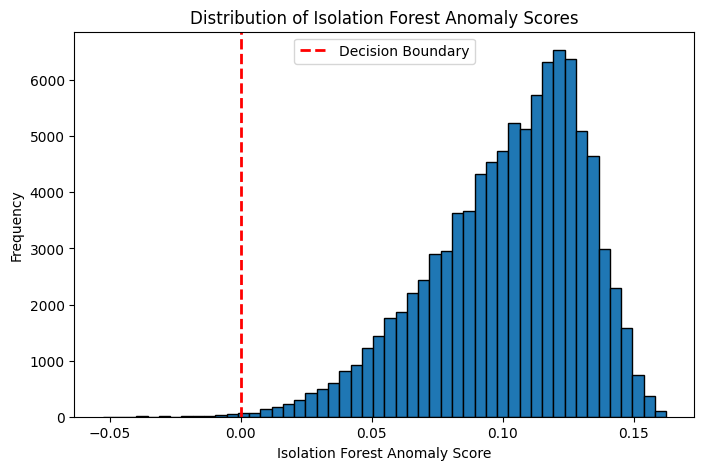

In [ ]:
import matplotlib.pyplot as plt

# Get anomaly scores
anomaly_scores = iso_forest.decision_function(X_train_scaled)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(anomaly_scores, bins=50, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Frequency")
plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.legend()
plt.show()

# Feature Engineering

In [ ]:
country_frequencies = X_train['country'].value_counts()
X_train['country_frequency'] = X_train['country'].map(country_frequencies)
X_train['country_frequency'].head()

,country_frequency
0,38960
1,38960
2,9710
3,9710
4,9710


In [ ]:
X_train['total_nights'] = X_train['stays_in_weekend_nights'] + X_train['stays_in_week_nights']
X_train['total_guests'] = X_train['adults'] + X_train['children'] + X_train['babies']

print(X_train[['total_nights', 'total_guests']].head())

   total_nights  total_guests
0             0             2
1             0             2
2             1             1
3             2             2
4             2             2


In [ ]:
X_train['room_type_assigned_as_reserved'] = (X_train['reserved_room_type'].astype(str) == X_train['assigned_room_type'].astype(str)).astype('category')
print(X_train[['reserved_room_type', 'assigned_room_type', 'room_type_assigned_as_reserved']].head())

  reserved_room_type assigned_room_type room_type_assigned_as_reserved
0                  C                  C                           True
1                  C                  C                           True
2                  A                  A                           True
3                  A                  A                           True
4                  A                  A                           True


In [ ]:
X_train['kids'] = ((X_train['children'] > 0) | (X_train['babies'] > 0)).astype('category')
X_train['kids'].value_counts()

,count
kids,
False,87786
True,7439


In [ ]:
X_train['total_previous_bookings'] = X_train['previous_cancellations'] + X_train['previous_bookings_not_canceled']
X_train['historical_cancellation_rate'] = (X_train['previous_cancellations'] / X_train['total_previous_bookings']).fillna(0)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95225 entries, 0 to 95224
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           95225 non-null  category
 1   lead_time                       95225 non-null  int64   
 2   arrival_date_year               95225 non-null  category
 3   arrival_date_month              95225 non-null  category
 4   arrival_date_week_number        95225 non-null  int64   
 5   arrival_date_day_of_month       95225 non-null  int64   
 6   stays_in_weekend_nights         95225 non-null  int64   
 7   stays_in_week_nights            95225 non-null  int64   
 8   adults                          95225 non-null  int64   
 9   children                        95225 non-null  int64   
 10  babies                          95225 non-null  int64   
 11  meal                            95225 non-null  category
 12  country           


Summary for 'lead_time':
Unique values: 477
count    95225.000000
mean       104.631798
std        107.741129
min          0.000000
25%         18.000000
50%         70.000000
75%        161.000000
max        737.000000
Name: lead_time, dtype: float64


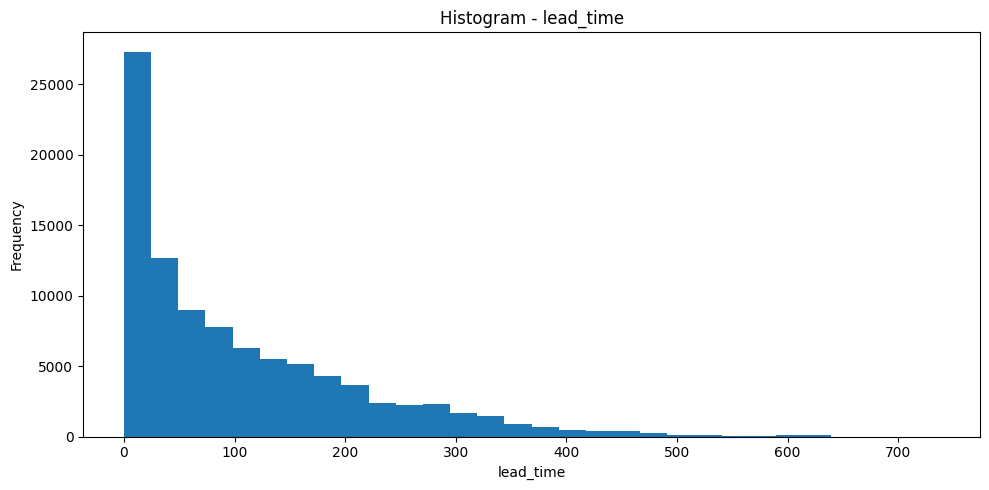

--------------------------------------------------

Summary for 'arrival_date_week_number':
Unique values: 53
                          Count  Percentage (%)
arrival_date_week_number                       
1                           838            0.88
2                           982            1.03
3                          1033            1.08
4                          1112            1.17
5                          1057            1.11
6                          1199            1.26
7                          1607            1.69
8                          1870            1.96
9                          1726            1.81
10                         1725            1.81
11                         1690            1.77
12                         1632            1.71
13                         1853            1.95
14                         1846            1.94
15                         2156            2.26
16                         1937            2.03
17                        

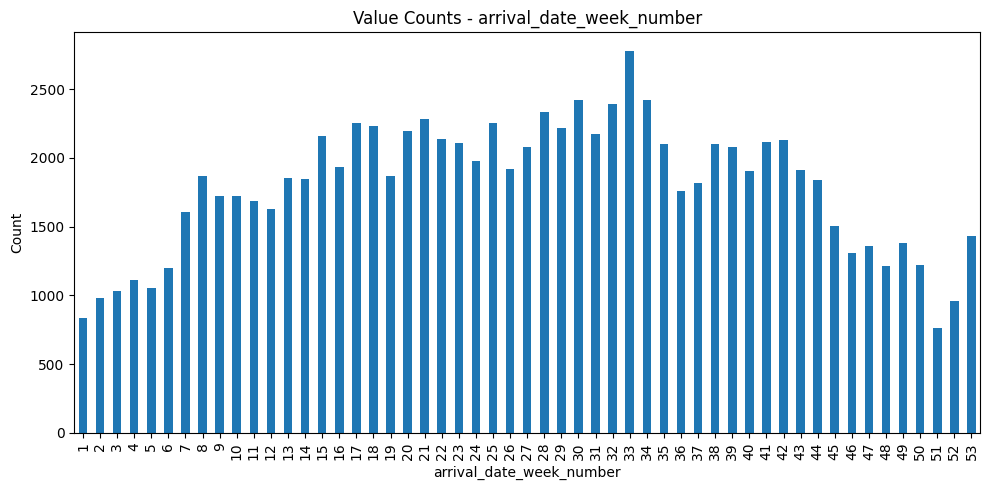

--------------------------------------------------

Summary for 'arrival_date_day_of_month':
Unique values: 31
                           Count  Percentage (%)
arrival_date_day_of_month                       
1                           2892            3.04
2                           3199            3.36
3                           3009            3.16
4                           3022            3.17
5                           3439            3.61
6                           3120            3.28
7                           2982            3.13
8                           3210            3.37
9                           3216            3.38
10                          2761            2.90
11                          2837            2.98
12                          3220            3.38
13                          3009            3.16
14                          3078            3.23
15                          3342            3.51
16                          3204            3.36
17     

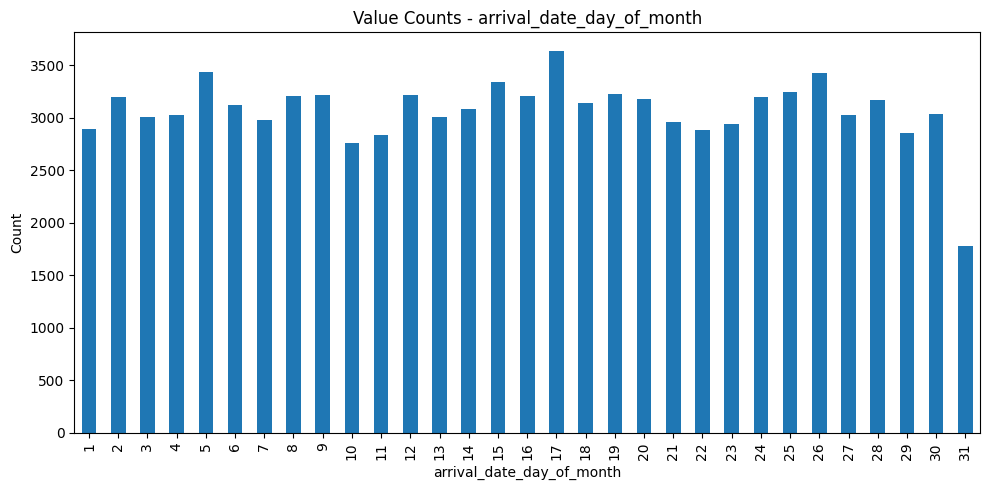

--------------------------------------------------

Summary for 'stays_in_weekend_nights':
Unique values: 15
                         Count  Percentage (%)
stays_in_weekend_nights                       
0                        41225           43.29
1                        24554           25.79
2                        26712           28.05
3                          982            1.03
4                         1470            1.54
5                           66            0.07
6                          121            0.13
7                           19            0.02
8                           51            0.05
9                           10            0.01
10                           5            0.01
12                           3            0.00
13                           3            0.00
14                           2            0.00
16                           2            0.00


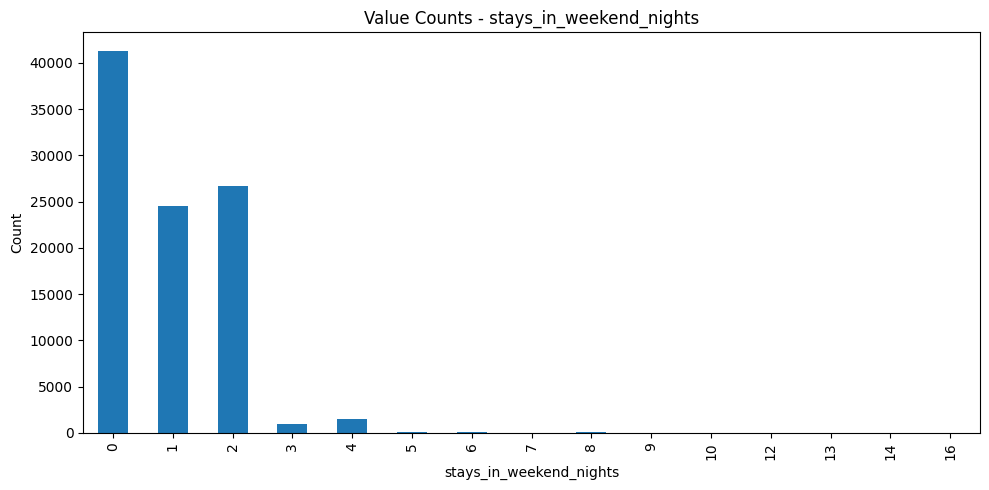

--------------------------------------------------

Summary for 'stays_in_week_nights':
Unique values: 32
                      Count  Percentage (%)
stays_in_week_nights                       
0                      5973            6.27
1                     24320           25.54
2                     26902           28.25
3                     17666           18.55
4                      7682            8.07
5                      8777            9.22
6                      1214            1.27
7                       828            0.87
8                       538            0.56
9                       184            0.19
10                      810            0.85
11                       44            0.05
12                       29            0.03
13                       25            0.03
14                       31            0.03
15                       67            0.07
16                       13            0.01
17                        3            0.00
18            

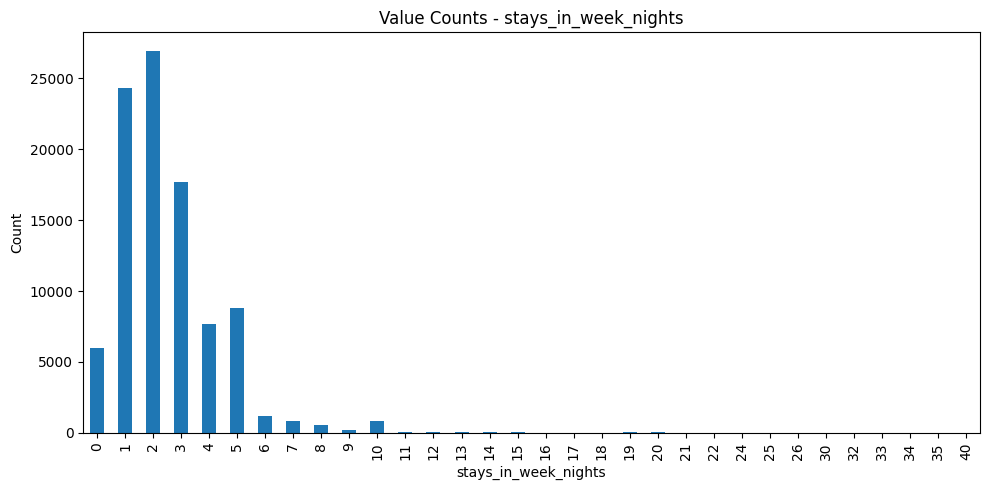

--------------------------------------------------

Summary for 'adults':
Unique values: 13
        Count  Percentage (%)
adults                       
0         320            0.34
1       18333           19.25
2       71511           75.10
3        4999            5.25
4          47            0.05
5           2            0.00
6           1            0.00
10          1            0.00
20          2            0.00
26          5            0.01
27          2            0.00
40          1            0.00
50          1            0.00


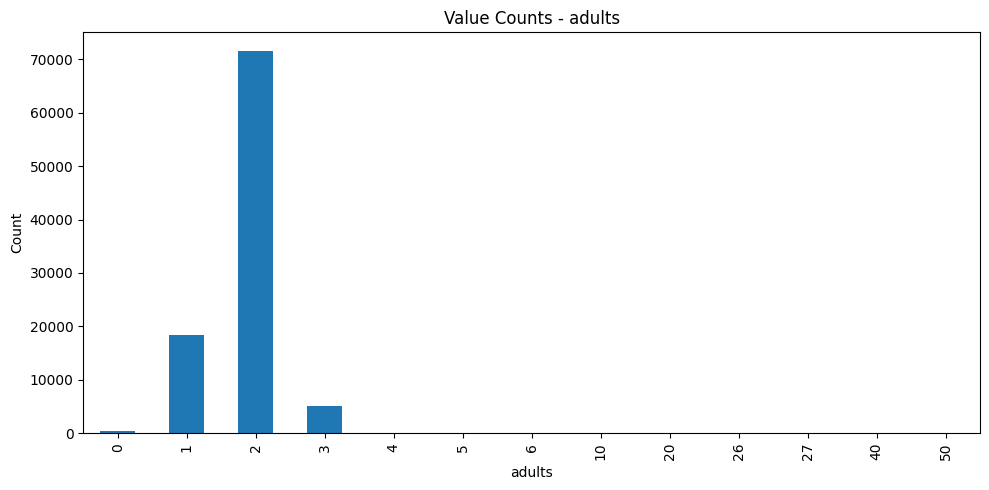

--------------------------------------------------

Summary for 'children':
Unique values: 5
          Count  Percentage (%)
children                       
0         88379           92.81
1          3840            4.03
2          2942            3.09
3            63            0.07
10            1            0.00


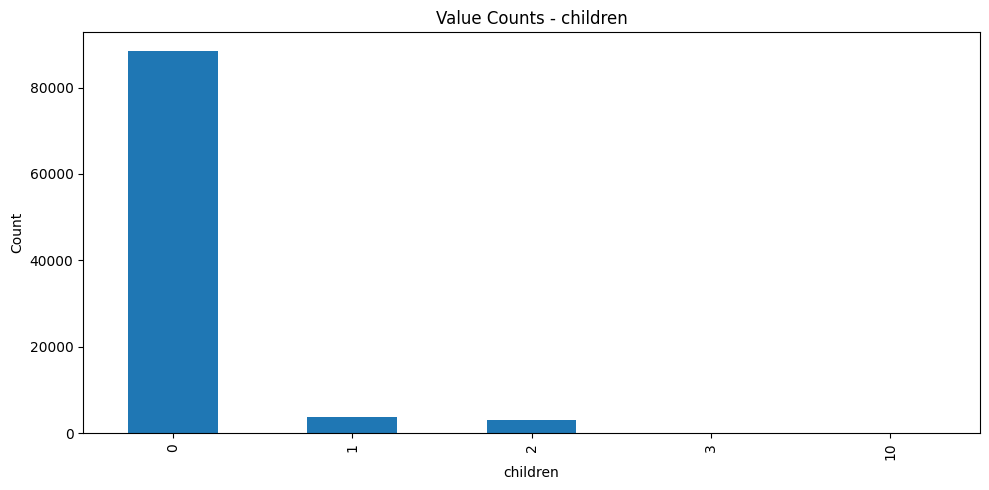

--------------------------------------------------

Summary for 'babies':
Unique values: 4
        Count  Percentage (%)
babies                       
0       94489           99.23
1         726            0.76
2           9            0.01
9           1            0.00


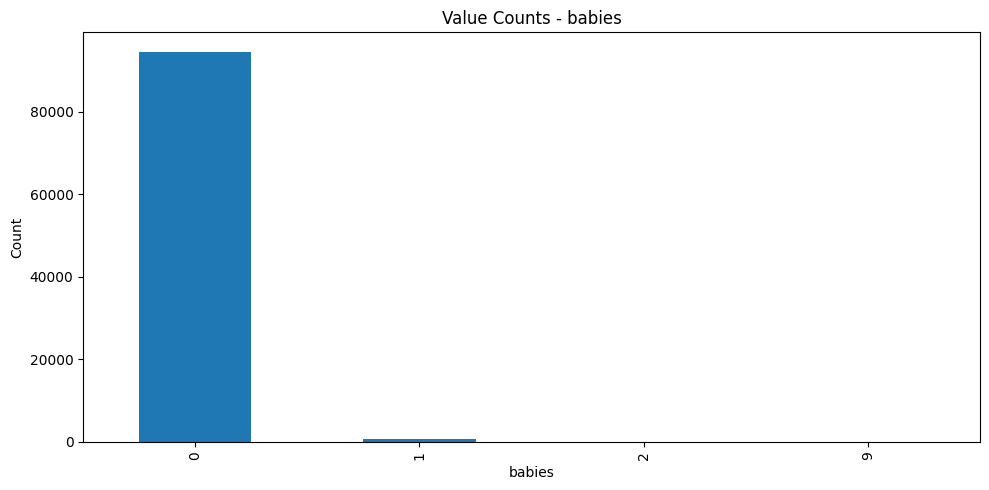

--------------------------------------------------

Summary for 'previous_cancellations':
Unique values: 13
                        Count  Percentage (%)
previous_cancellations                       
0                       90131           94.65
1                        4778            5.02
2                          93            0.10
3                          56            0.06
4                          23            0.02
5                          15            0.02
6                          19            0.02
11                         28            0.03
13                         12            0.01
19                         19            0.02
24                         24            0.03
25                          1            0.00
26                         26            0.03


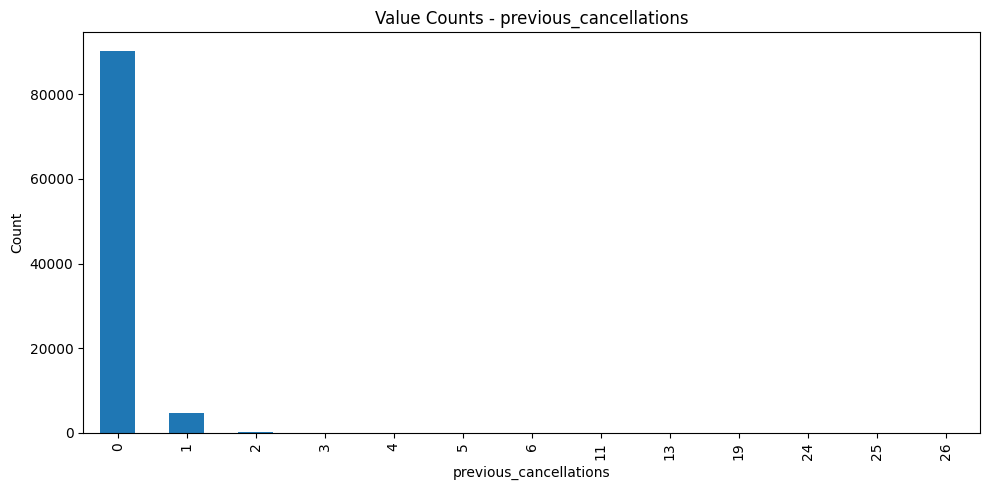

--------------------------------------------------

Summary for 'previous_bookings_not_canceled':
Unique values: 64
                                Count  Percentage (%)
previous_bookings_not_canceled                       
0                               92547           97.19
1                                1135            1.19
2                                 430            0.45
3                                 234            0.25
4                                 165            0.17
...                               ...             ...
67                                  1            0.00
68                                  1            0.00
69                                  1            0.00
70                                  1            0.00
72                                  1            0.00

[64 rows x 2 columns]


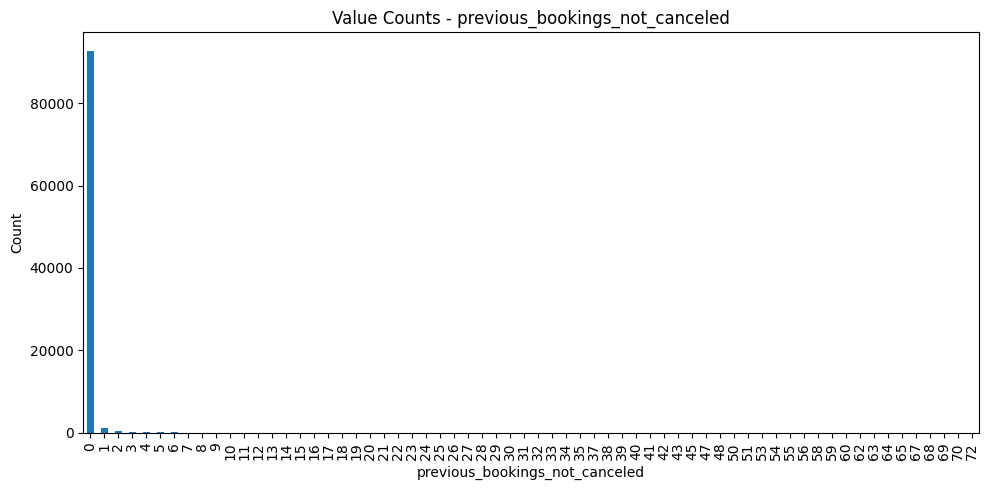

--------------------------------------------------

Summary for 'booking_changes':
Unique values: 20
                 Count  Percentage (%)
booking_changes                       
0                80812           84.86
1                10178           10.69
2                 2975            3.12
3                  764            0.80
4                  295            0.31
5                   90            0.09
6                   51            0.05
7                   22            0.02
8                   10            0.01
9                    5            0.01
10                   4            0.00
11                   1            0.00
12                   1            0.00
13                   5            0.01
14                   5            0.01
15                   2            0.00
16                   1            0.00
17                   2            0.00
20                   1            0.00
21                   1            0.00


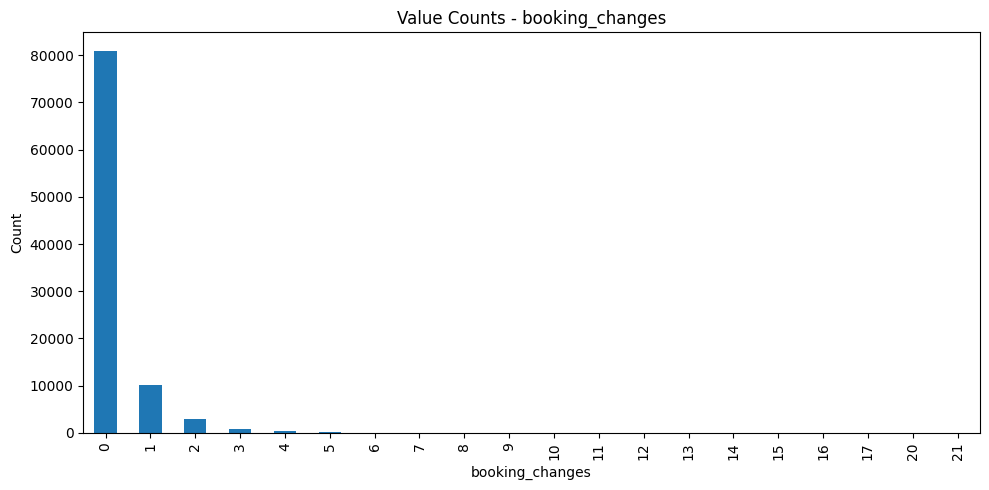

--------------------------------------------------

Summary for 'days_in_waiting_list':
Unique values: 122
                      Count  Percentage (%)
days_in_waiting_list                       
0                     92416           97.05
1                         8            0.01
2                         4            0.00
3                        59            0.06
4                        14            0.01
...                     ...             ...
236                      29            0.03
259                       9            0.01
330                       6            0.01
379                       2            0.00
391                      45            0.05

[122 rows x 2 columns]


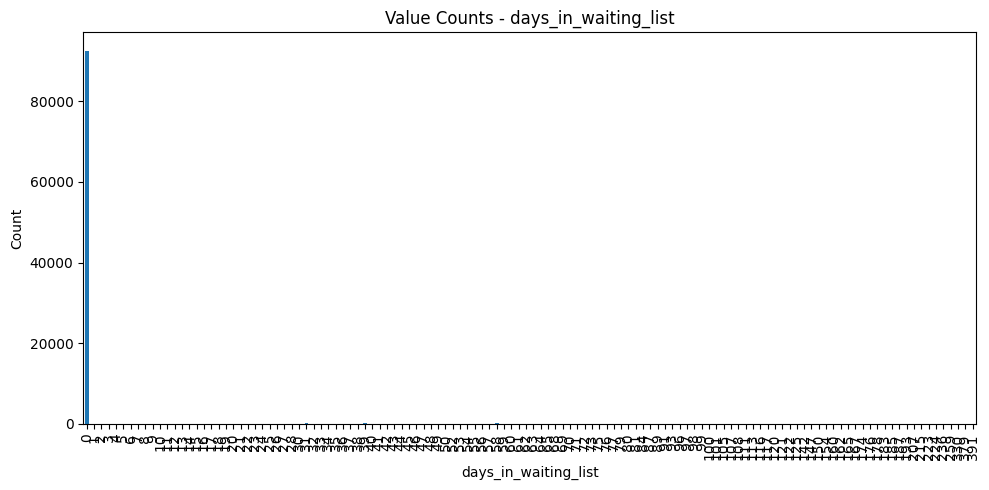

--------------------------------------------------

Summary for 'adr':
Unique values: 7921
count    95225.000000
mean       102.080471
std         48.052823
min          0.000000
25%         70.000000
50%         95.000000
75%        126.000000
max        510.000000
Name: adr, dtype: float64


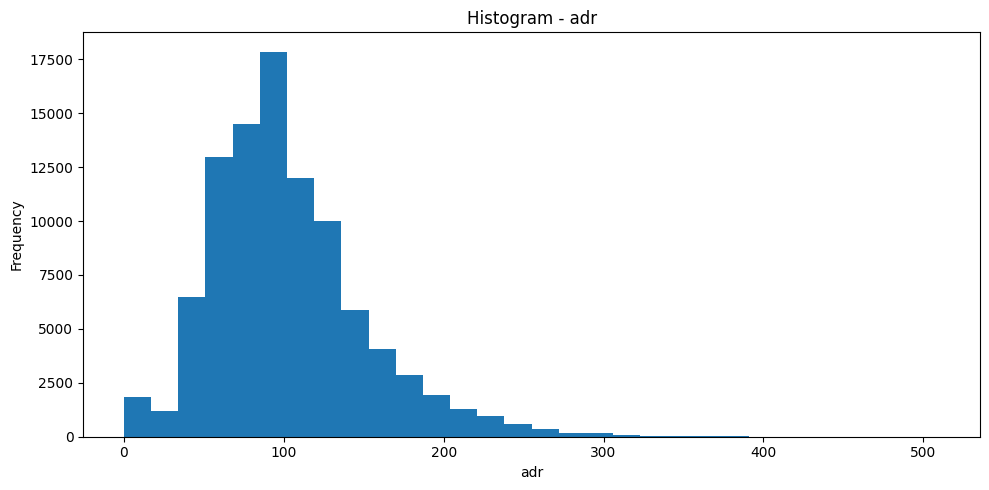

--------------------------------------------------

Summary for 'required_car_parking_spaces':
Unique values: 5
                             Count  Percentage (%)
required_car_parking_spaces                       
0                            89390           93.87
1                             5808            6.10
2                               23            0.02
3                                3            0.00
8                                1            0.00


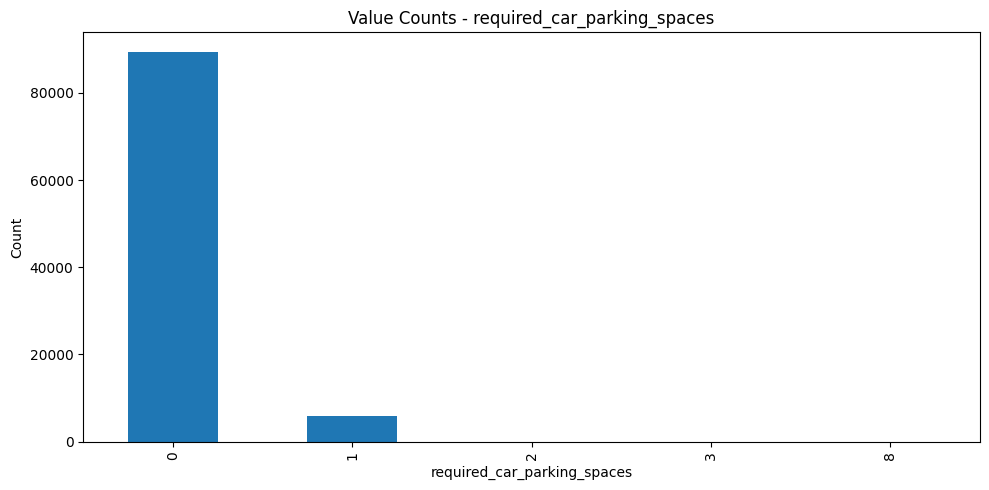

--------------------------------------------------

Summary for 'total_of_special_requests':
Unique values: 6
                           Count  Percentage (%)
total_of_special_requests                       
0                          56055           58.87
1                          26631           27.97
2                          10276           10.79
3                           1978            2.08
4                            259            0.27
5                             26            0.03


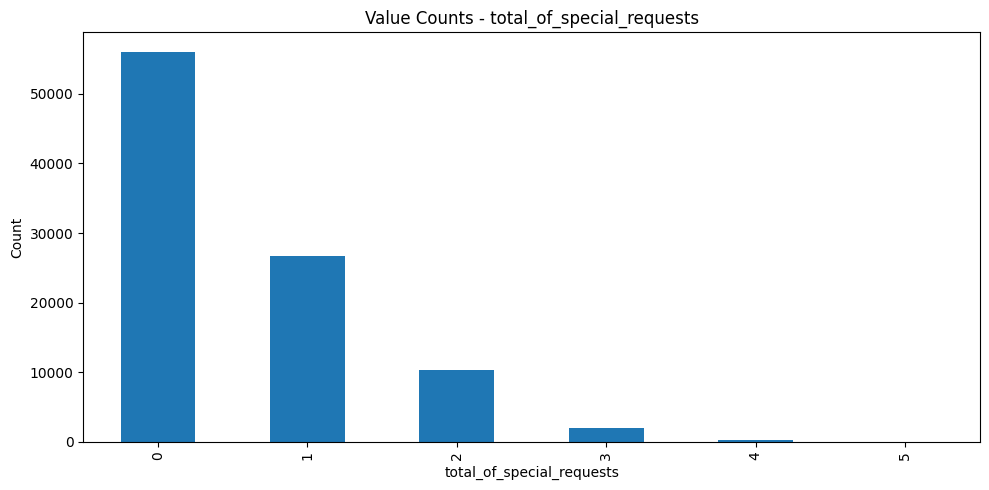

--------------------------------------------------

Summary for 'country_frequency':
Unique values: 82
                   Count  Percentage (%)
country_frequency                       
1                     28            0.03
2                     38            0.04
3                     21            0.02
4                     32            0.03
5                     35            0.04
...                  ...             ...
5871                5871            6.17
6935                6935            7.28
8323                8323            8.74
9710                9710           10.20
38960              38960           40.91

[82 rows x 2 columns]


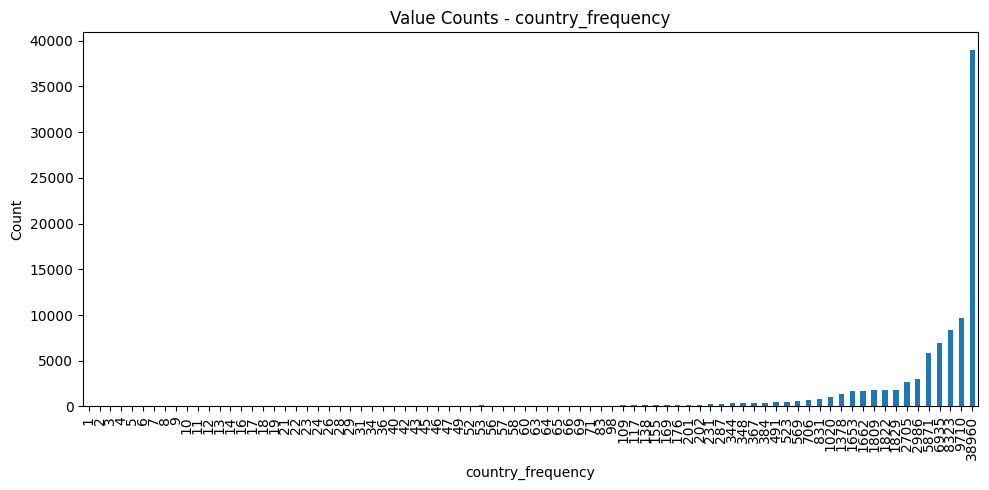

--------------------------------------------------

Summary for 'total_nights':
Unique values: 42
              Count  Percentage (%)
total_nights                       
0               562            0.59
1             16697           17.53
2             22027           23.13
3             21576           22.66
4             13925           14.62
5              6217            6.53
6              3105            3.26
7              6908            7.25
8               924            0.97
9               676            0.71
10              926            0.97
11              320            0.34
12              176            0.18
13              105            0.11
14              722            0.76
15               57            0.06
16               29            0.03
17               20            0.02
18               29            0.03
19               19            0.02
20               12            0.01
21               53            0.06
22               12            0.01
23

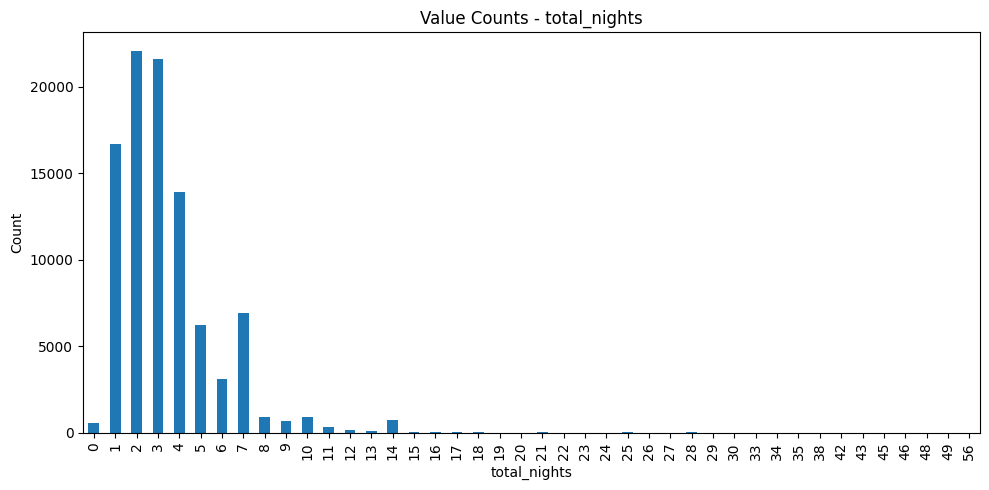

--------------------------------------------------

Summary for 'total_guests':
Unique values: 14
              Count  Percentage (%)
total_guests                       
0               136            0.14
1             17976           18.88
2             65438           68.72
3              8395            8.82
4              3158            3.32
5               107            0.11
6                 1            0.00
10                2            0.00
12                1            0.00
20                2            0.00
26                5            0.01
27                2            0.00
40                1            0.00
50                1            0.00


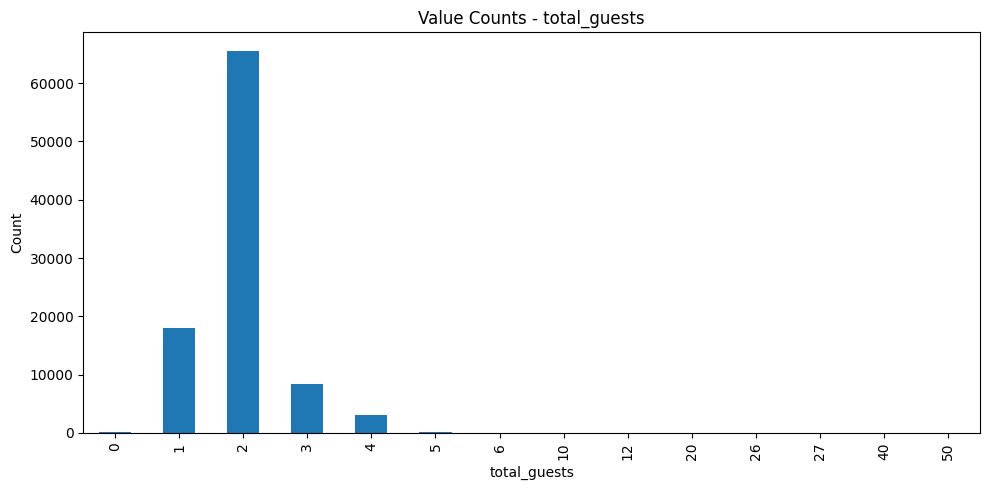

--------------------------------------------------

Summary for 'total_previous_bookings':
Unique values: 67
                         Count  Percentage (%)
total_previous_bookings                       
0                        87959           92.37
1                         5554            5.83
2                          454            0.48
3                          241            0.25
4                          167            0.18
...                        ...             ...
73                           1            0.00
74                           1            0.00
75                           1            0.00
76                           1            0.00
78                           1            0.00

[67 rows x 2 columns]


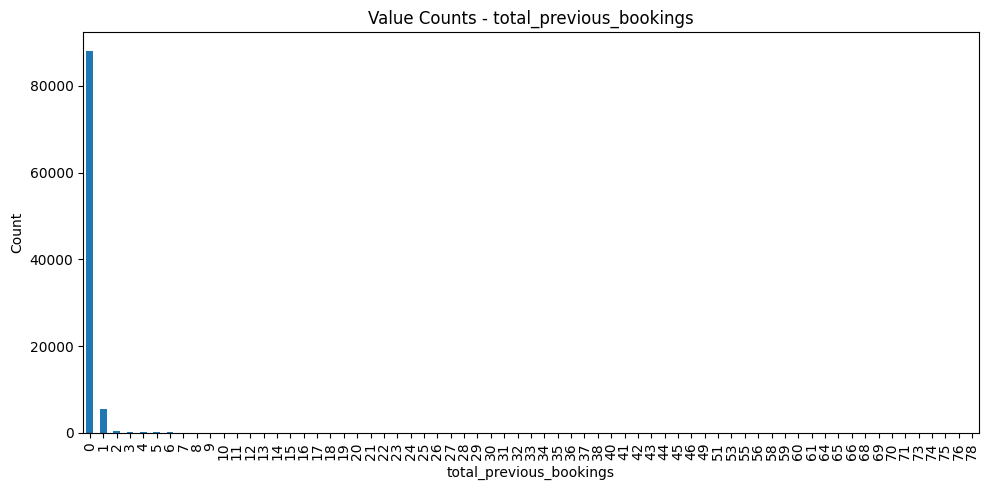

--------------------------------------------------

Summary for 'historical_cancellation_rate':
Unique values: 101
                              Count  Percentage (%)
historical_cancellation_rate                       
0.000000                      90131           94.65
0.032258                          1            0.00
0.033333                          1            0.00
0.034483                          3            0.00
0.035714                          2            0.00
...                             ...             ...
0.733333                          5            0.01
0.750000                          1            0.00
0.916667                          1            0.00
0.928571                         11            0.01
1.000000                       4588            4.82

[101 rows x 2 columns]


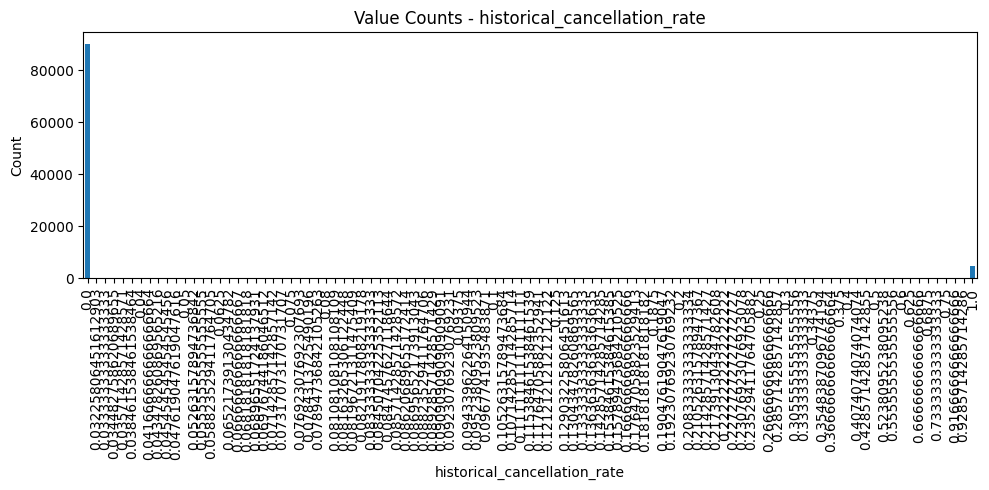

--------------------------------------------------


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get all numerical columns
numerical_columns = X_train.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    print(f"\nSummary for '{col}':")

    unique_count = X_train[col].nunique(dropna=True)
    print(f"Unique values: {unique_count}")

    # Show value counts if reasonably sized
    if unique_count <= 250:
        counts = X_train[col].value_counts().sort_index()

        summary = pd.DataFrame({
            'Count': counts,
            'Percentage (%)': (counts / len(X_train) * 100).round(2)
        })

        print(summary)

        # Bar plot
        plt.figure(figsize=(10, 5))
        counts.plot(kind='bar')
        plt.title(f'Value Counts - {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

    else:
        # Basic statistics
        print(X_train[col].describe())

        # Histogram
        plt.figure(figsize=(10, 5))
        plt.hist(X_train[col].dropna(), bins=30)
        plt.title(f'Histogram - {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

    print("-" * 50)

# Preprocessing

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from scipy.stats import randint

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [ ]:
# Feature Engineering for X_test
X_test['total_nights'] = X_test['stays_in_weekend_nights'] + X_test['stays_in_week_nights']
X_test['total_guests'] = X_test['adults'] + X_test['children'] + X_test['babies']
X_test['room_type_assigned_as_reserved'] = (X_test['reserved_room_type'].astype(str) == X_test['assigned_room_type'].astype(str)).astype('category')
X_test['kids'] = ((X_test['children'] > 0) | (X_test['babies'] > 0)).astype('category')
X_test['total_previous_bookings'] = X_test['previous_cancellations'] + X_test['previous_bookings_not_canceled']
X_test['historical_cancellation_rate'] = (X_test['previous_cancellations'] / X_test['total_previous_bookings']).fillna(0)
X_test["country_frequency"] = X_test["country"].map(country_frequencies)
# Handle countries in the test set that were not seen during training
X_test["country_frequency"] = X_test["country_frequency"].fillna(1)


In [ ]:
# List of original features to drop because we have engineered versions
'''drop_originals = [
    'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
    'children', 'babies', 'reserved_room_type', 'assigned_room_type',
    'previous_cancellations', 'previous_bookings_not_canceled'
]'''
drop_originals = [
    'days_in_waiting_list','arrival_date_year','assigned_room_type','booking_changes'
]

# Your specific exclusions
exclusions = ['country','historical_cancellation_rate','room_type_assigned_as_reserved']

# Final Feature set
X_train = X_train.drop(columns=drop_originals + exclusions)
X_test = X_test.drop(columns=drop_originals + exclusions)

In [ ]:
# REMOVE REDUNDANT FEATURES
features_to_remove = [
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "total_guests",
    "children",
    "babies",
    "total_previous_bookings",
]

X_train = X_train.drop(columns=features_to_remove)
X_test = X_test.drop(columns=features_to_remove)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95225 entries, 0 to 95224
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           95225 non-null  category
 1   lead_time                       95225 non-null  int64   
 2   arrival_date_month              95225 non-null  category
 3   arrival_date_week_number        95225 non-null  int64   
 4   arrival_date_day_of_month       95225 non-null  int64   
 5   adults                          95225 non-null  int64   
 6   meal                            95225 non-null  category
 7   market_segment                  95225 non-null  category
 8   distribution_channel            95225 non-null  category
 9   is_repeated_guest               95225 non-null  category
 10  previous_cancellations          95225 non-null  int64   
 11  previous_bookings_not_canceled  95225 non-null  int64   
 12  reserved_room_type

Checking for multicollinearity

In [ ]:
import pandas as pd

from statsmodels.stats.outliers_influence import variance_inflation_factor


# SELECT NUMERICAL FEATURES
X_train_num = X_train.select_dtypes(include="number")


# CALCULATE VIF
vif = pd.DataFrame()

vif["Feature"] = X_train_num.columns

vif["VIF"] = [
    variance_inflation_factor(X_train_num.values, i)
    for i in range(X_train_num.shape[1])
]

vif = vif.sort_values("VIF", ascending=False).reset_index(drop=True)

print(vif)

                           Feature       VIF
0                           adults  8.678966
1                              adr  5.703958
2         arrival_date_week_number  4.630887
3        arrival_date_day_of_month  3.776896
4                     total_nights  2.825664
5                country_frequency  2.204917
6                        lead_time  2.157817
7        total_of_special_requests  1.662383
8      required_car_parking_spaces  1.089447
9           previous_cancellations  1.071046
10  previous_bookings_not_canceled  1.066912


In [ ]:
X_train.select_dtypes(include="number").corr()["adults"].sort_values(ascending=False)

,adults
adults,1.000000
adr,0.239354
total_of_special_requests,0.125370
lead_time,0.119976
total_nights,0.105747
arrival_date_week_number,0.024367
required_car_parking_spaces,0.015221
arrival_date_day_of_month,0.001944
previous_cancellations,-0.009454
previous_bookings_not_canceled,-0.106079


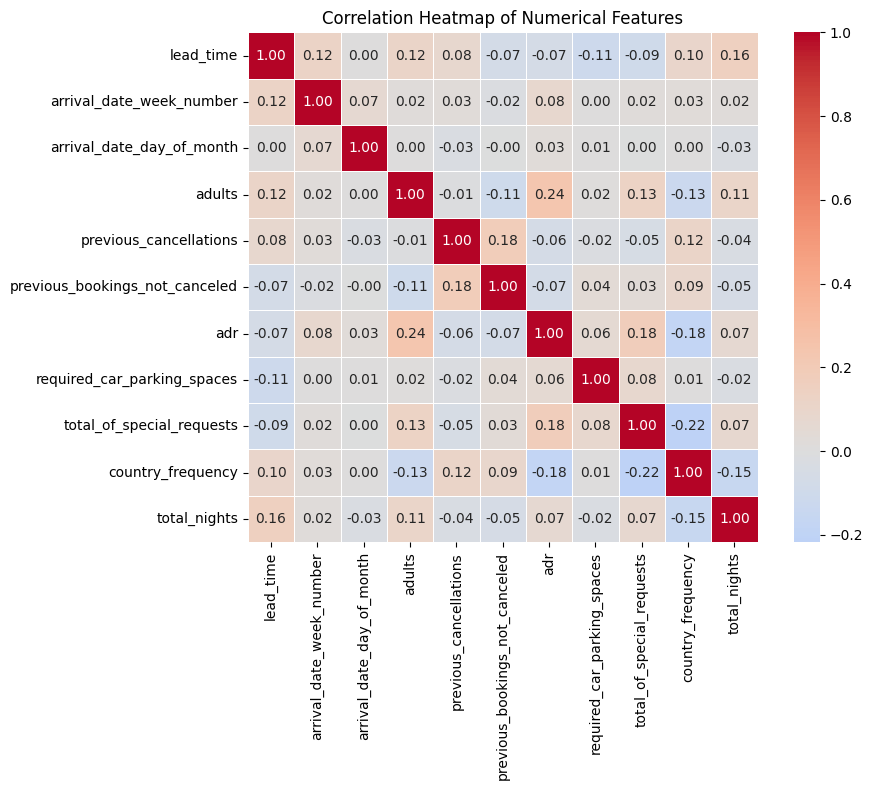

In [ ]:

# CORRELATION MATRIX (NUMERICAL FEATURES)
X_train_num = X_train.select_dtypes(include="number")

corr_matrix = X_train_num.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

# Model Fitting

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95225 entries, 0 to 95224
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           95225 non-null  category
 1   lead_time                       95225 non-null  int64   
 2   arrival_date_month              95225 non-null  category
 3   arrival_date_week_number        95225 non-null  int64   
 4   arrival_date_day_of_month       95225 non-null  int64   
 5   adults                          95225 non-null  int64   
 6   meal                            95225 non-null  category
 7   market_segment                  95225 non-null  category
 8   distribution_channel            95225 non-null  category
 9   is_repeated_guest               95225 non-null  category
 10  previous_cancellations          95225 non-null  int64   
 11  previous_bookings_not_canceled  95225 non-null  int64   
 12  reserved_room_type

## Fitting Linear Models

### Linear Baselines

In [ ]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =====================================================
# IDENTIFY FEATURE TYPES
# =====================================================

numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include="category"
).columns.tolist()

# =====================================================
# PREPROCESSOR
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

# =====================================================
# BASELINE MODELS
# =====================================================

models = {

    "Logistic Regression (No Reg) (Baseline)": LogisticRegression(
        penalty=None,
        max_iter=1000,
        random_state=42
    ),

    "Ridge Logistic (L2) (Baseline)": LogisticRegression(
        penalty="l2",
        max_iter=1000,
        random_state=42
    ),

    "Lasso Logistic (L1) (Baseline)": LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ),

    "Elastic Net Logistic (Baseline)": LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        max_iter=1000,
        random_state=42
    )
}

# =====================================================
# CROSS VALIDATION SETUP
# =====================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# =====================================================
# CROSS VALIDATE & TEST EVALUATION
# =====================================================

baseline_linear_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Cross-validation on training data
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    # Train on full training set
    pipeline.fit(X_train, y_train)

    # Test set evaluation
    y_pred = pipeline.predict(X_test)

    baseline_linear_results.append({
        "Model": name,
        "Estimator": pipeline,

        "CV Accuracy": cv_results["test_accuracy"].mean(),
        "CV Precision": cv_results["test_precision"].mean(),
        "CV Recall": cv_results["test_recall"].mean(),
        "CV F1": cv_results["test_f1"].mean(),

        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred)
    })

# =====================================================
# RESULTS
# =====================================================

baseline_linear_df = pd.DataFrame(baseline_linear_results)

print("Baseline Linear Model Performance")
print(
    baseline_linear_df
    .drop(columns="Estimator")
    .round(4)
    .to_string(index=False)
)

Baseline Linear Model Performance
                                  Model  CV Accuracy  CV Precision  CV Recall  CV F1  Test Accuracy  Test Precision  Test Recall  Test F1
Logistic Regression (No Reg) (Baseline)       0.8022        0.8068     0.6146 0.6977         0.8028          0.8060       0.6167   0.6988
         Ridge Logistic (L2) (Baseline)       0.8023        0.8065     0.6153 0.6980         0.8023          0.8058       0.6153   0.6978
         Lasso Logistic (L1) (Baseline)       0.8022        0.8069     0.6146 0.6977         0.8028          0.8071       0.6153   0.6983
        Elastic Net Logistic (Baseline)       0.8023        0.8064     0.6154 0.6980         0.8022          0.8059       0.6151   0.6977


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Tune Linear Models

In [ ]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =====================================================
# IDENTIFY FEATURE TYPES
# =====================================================

numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# =====================================================
# PREPROCESSOR
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

# =====================================================
# MODELS
# =====================================================

models = {

    "Logistic Regression (No Regularization)": (
        LogisticRegression(
            penalty=None,
            max_iter=1000,
            random_state=42
        ),
        None
    ),

    "Ridge Logistic (L2)": (
        LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            random_state=42
        ),
        {
            "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
        }
    ),

    "Lasso Logistic (L1)": (
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=1000,
            random_state=42
        ),
        {
            "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
        }
    ),

    "Elastic Net Logistic": (
        LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            max_iter=1000,
            random_state=42
        ),
        {
            "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
            "model__l1_ratio": [0.2, 0.4, 0.6, 0.8]
        }
    )
}

# =====================================================
# CROSS VALIDATION
# =====================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# =====================================================
# TRAIN & EVALUATE
# =====================================================

tuned_linear_results = []

for name, (model, params) in models.items():

    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # -------------------------------------------------
    # No hyperparameter tuning
    # -------------------------------------------------

    if params is None:

        cv_scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        pipeline.fit(X_train, y_train)

        best_pipeline = pipeline
        best_params = None

        cv_accuracy = cv_scores["test_accuracy"].mean()
        cv_precision = cv_scores["test_precision"].mean()
        cv_recall = cv_scores["test_recall"].mean()
        cv_f1 = cv_scores["test_f1"].mean()

    # -------------------------------------------------
    # Hyperparameter tuning
    # -------------------------------------------------

    else:

        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=params,
            n_iter=5,
            scoring=scoring,
            refit="f1",
            cv=cv,
            random_state=42,
            n_jobs=-1,
            return_train_score=False
        )

        search.fit(X_train, y_train)

        best_pipeline = search.best_estimator_
        best_params = search.best_params_

        best_idx = search.best_index_
        results = search.cv_results_

        cv_accuracy = results["mean_test_accuracy"][best_idx]
        cv_precision = results["mean_test_precision"][best_idx]
        cv_recall = results["mean_test_recall"][best_idx]
        cv_f1 = results["mean_test_f1"][best_idx]

    # -------------------------------------------------
    # Test evaluation
    # -------------------------------------------------

    y_pred = best_pipeline.predict(X_test)

    tuned_linear_results.append({

        "Model": name,

        "CV Accuracy": cv_accuracy,
        "CV Precision": cv_precision,
        "CV Recall": cv_recall,
        "CV F1": cv_f1,

        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),

        "Best Parameters": best_params,

        "Estimator": best_pipeline
    })

# =====================================================
# RESULTS
# =====================================================

tuned_linear_df = pd.DataFrame(tuned_linear_results)

print("\nTuned Linear Model Performance\n")

performance_table = tuned_linear_df[
    [
        "Model",
        "CV Accuracy",
        "CV Precision",
        "CV Recall",
        "CV F1",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1"
    ]
].round(4)

print(performance_table.to_string(index=False))

print("\nBest Hyperparameters\n")

print(
    tuned_linear_df[
        ["Model", "Best Parameters"]
    ].to_string(index=False)
)


Training Logistic Regression (No Regularization)...

Training Ridge Logistic (L2)...

Training Lasso Logistic (L1)...

Training Elastic Net Logistic...

Tuned Linear Model Performance

                                  Model  CV Accuracy  CV Precision  CV Recall  CV F1  Test Accuracy  Test Precision  Test Recall  Test F1
Logistic Regression (No Regularization)       0.8022        0.8068     0.6146 0.6977         0.8028          0.8060       0.6167   0.6988
                    Ridge Logistic (L2)       0.8023        0.8060     0.6159 0.6982         0.8027          0.8063       0.6161   0.6985
                    Lasso Logistic (L1)       0.8024        0.8075     0.6146 0.6979         0.8024          0.8064       0.6151   0.6978
                   Elastic Net Logistic       0.8023        0.8064     0.6154 0.6980         0.8022          0.8055       0.6155   0.6978

Best Hyperparameters

                                  Model                          Best Parameters
Logistic Regression 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95225 entries, 0 to 95224
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           95225 non-null  category
 1   lead_time                       95225 non-null  int64   
 2   arrival_date_month              95225 non-null  category
 3   arrival_date_week_number        95225 non-null  int64   
 4   arrival_date_day_of_month       95225 non-null  int64   
 5   adults                          95225 non-null  int64   
 6   meal                            95225 non-null  category
 7   market_segment                  95225 non-null  category
 8   distribution_channel            95225 non-null  category
 9   is_repeated_guest               95225 non-null  category
 10  previous_cancellations          95225 non-null  int64   
 11  previous_bookings_not_canceled  95225 non-null  int64   
 12  reserved_room_type

## Fitting Tree Based Models

In [ ]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


### Tree Baselines

In [ ]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =====================================================
# IDENTIFY FEATURE TYPES
# =====================================================

numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# =====================================================
# PREPROCESSOR
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

# =====================================================
# BASELINE TREE MODELS
# =====================================================

tree_models = {

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0
    )
}

# =====================================================
# 5-FOLD STRATIFIED CROSS VALIDATION
# =====================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# =====================================================
# TRAIN, CROSS-VALIDATE & TEST
# =====================================================

baseline_tree_results = []

for name, model in tree_models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # -----------------------------
    # 5-Fold Cross Validation
    # -----------------------------
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    # -----------------------------
    # Train on Full Training Set
    # -----------------------------
    pipeline.fit(X_train, y_train)

    # -----------------------------
    # Evaluate on Test Set
    # -----------------------------
    y_pred = pipeline.predict(X_test)

    baseline_tree_results.append({

        "Model": name,

        # Cross-validation metrics
        "CV Accuracy": cv_scores["test_accuracy"].mean(),
        "CV Precision": cv_scores["test_precision"].mean(),
        "CV Recall": cv_scores["test_recall"].mean(),
        "CV F1": cv_scores["test_f1"].mean(),

        # Test metrics
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),

        # Save trained model
        "Estimator": pipeline
    })

# =====================================================
# RESULTS
# =====================================================

baseline_tree_df = pd.DataFrame(baseline_tree_results)

print("\nBaseline Tree-Based Models (5-Fold CV + Test Set)\n")

print(
    baseline_tree_df.drop(columns="Estimator").round(4).to_string(index=False)
)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Baseline Tree-Based Models (5-Fold CV + Test Set)

        Model  CV Accuracy  CV Precision  CV Recall  CV F1  Test Accuracy  Test Precision  Test Recall  Test F1
Random Forest       0.8796        0.8697     0.7948 0.8306         0.8611          0.8614       0.7455   0.7993
      XGBoost       0.8632        0.8410     0.7790 0.8088         0.8548          0.8340       0.7597   0.7951
     LightGBM       0.8567        0.8391     0.7601 0.7977         0.8515          0.8350       0.7475   0.7888
     CatBoost       0.8648        0.8463     0.7772 0.8103         0.8632          0.8486       0.7681   0.8064


### Tune Tree Based Models

In [ ]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# =====================================================
# IDENTIFY FEATURE TYPES
# =====================================================

numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# =====================================================
# PREPROCESSOR
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

# =====================================================
# MODELS & PARAMETER DISTRIBUTIONS
# =====================================================

tree_models = {

    "Random Forest": (
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ),
        {
            "model__n_estimators": [100, 200, 300, 500],
            "model__max_depth": [None, 10, 20, 30, 40],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", None]
        }
    ),

    "XGBoost": (
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ),
        {
            "model__n_estimators": [100, 200, 300, 500],
            "model__max_depth": [3, 5, 7, 9],
            "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "model__subsample": [0.6, 0.8, 1.0],
            "model__colsample_bytree": [0.6, 0.8, 1.0]
        }
    ),

    "LightGBM": (
        LGBMClassifier(
            random_state=42,
            verbose=-1
        ),
        {
            "model__n_estimators": [100, 200, 300, 500],
            "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "model__max_depth": [-1, 5, 10, 20],
            "model__num_leaves": [31, 50, 100],
            "model__subsample": [0.6, 0.8, 1.0]
        }
    ),

    "CatBoost": (
        CatBoostClassifier(
            random_state=42,
            verbose=0
        ),
        {
            "model__iterations": [100, 200, 300, 500],
            "model__depth": [4, 6, 8, 10],
            "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "model__l2_leaf_reg": [1, 3, 5, 7, 9]
        }
    )
}

# =====================================================
# 5-FOLD STRATIFIED CV
# =====================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =====================================================
# MULTIPLE SCORING METRICS
# =====================================================

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# =====================================================
# HYPERPARAMETER TUNING
# =====================================================

tuned_tree_results = []

for name, (model, params) in tree_models.items():

    print(f"\nTuning {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=params,
        n_iter=5,
        scoring=scoring,
        refit="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        return_train_score=False
    )

    random_search.fit(X_train, y_train)

    best_pipeline = random_search.best_estimator_

    # Best CV metrics
    best_idx = random_search.best_index_
    cv_results = random_search.cv_results_

    # Test predictions
    y_pred = best_pipeline.predict(X_test)

    tuned_tree_results.append({

        "Model": name,

        "CV Accuracy": cv_results["mean_test_accuracy"][best_idx],
        "CV Precision": cv_results["mean_test_precision"][best_idx],
        "CV Recall": cv_results["mean_test_recall"][best_idx],
        "CV F1": cv_results["mean_test_f1"][best_idx],

        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),

        "Best Parameters": random_search.best_params_,

        "Estimator": best_pipeline
    })

# =====================================================
# RESULTS DATAFRAME
# =====================================================

tuned_tree_df = pd.DataFrame(tuned_tree_results)

# =====================================================
# CLEAN PERFORMANCE TABLE
# =====================================================

print("\nTuned Tree-Based Model Performance\n")

performance_table = tuned_tree_df[
    [
        "Model",
        "CV Accuracy",
        "CV Precision",
        "CV Recall",
        "CV F1",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1"
    ]
].round(4)

print(performance_table.to_string(index=False))

# =====================================================
# OPTIONAL: BEST PARAMETERS
# =====================================================

print("\nBest Hyperparameters\n")

print(
    tuned_tree_df[
        ["Model", "Best Parameters"]
    ].to_string(index=False)
)


Tuning Random Forest...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Tuning LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Tuning CatBoost...

Tuned Tree-Based Model Performance

        Model  CV Accuracy  CV Precision  CV Recall  CV F1  Test Accuracy  Test Precision  Test Recall  Test F1
Random Forest       0.8813        0.8711     0.7987 0.8333         0.8630          0.8614       0.7515   0.8027
      XGBoost       0.8618        0.8430     0.7715 0.8057         0.8567          0.8390       0.7595   0.7973
     LightGBM       0.8657        0.8448     0.7822 0.8123         0.8584          0.8374       0.7673   0.8009
     CatBoost       0.8692        0.8504     0.7861 0.8170         0.8608          0.8444       0.7661   0.8033

Best Hyperparameters

        Model                                                                                                                                  Best Parameters
Random Forest {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 40}
      XGBoost       {'model__subsample': 0

## Comparison and Best Model Selection

In [ ]:
# =====================================================
# COMBINE ALL MODEL RESULTS
# =====================================================

all_models_df = pd.concat(
    [
        baseline_linear_df,
        tuned_linear_df,
        baseline_tree_df,
        tuned_tree_df
    ],
    ignore_index=True,
    sort=False
)

In [ ]:
# =====================================================
# RANK MODELS
# =====================================================

ranking = (
    all_models_df
    .sort_values(
        by=["Test F1", "CV F1", "Test Accuracy"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nOverall Model Ranking\n")

print(
    ranking[
        [
            "Model",
            "CV Accuracy",
            "CV Precision",
            "CV Recall",
            "CV F1",
            "Test Accuracy",
            "Test Precision",
            "Test Recall",
            "Test F1"
        ]
    ]
    .round(4)
    .to_string(index=False)
)


Overall Model Ranking

                                  Model  CV Accuracy  CV Precision  CV Recall  CV F1  Test Accuracy  Test Precision  Test Recall  Test F1
                               CatBoost       0.8648        0.8463     0.7772 0.8103         0.8632          0.8486       0.7681   0.8064
                               CatBoost       0.8692        0.8504     0.7861 0.8170         0.8608          0.8444       0.7661   0.8033
                          Random Forest       0.8813        0.8711     0.7987 0.8333         0.8630          0.8614       0.7515   0.8027
                               LightGBM       0.8657        0.8448     0.7822 0.8123         0.8584          0.8374       0.7673   0.8009
                          Random Forest       0.8796        0.8697     0.7948 0.8306         0.8611          0.8614       0.7455   0.7993
                                XGBoost       0.8618        0.8430     0.7715 0.8057         0.8567          0.8390       0.7595   0.7973
          

## Best Model

In [ ]:
# =====================================================
# BEST MODEL
# =====================================================

best_row = ranking.iloc[0]

best_model_name = best_row["Model"]
best_pipeline = best_row["Estimator"]

print("\n" + "="*70)
print("BEST MODEL")
print("="*70)

print(f"Model           : {best_model_name}")
print(f"CV Accuracy     : {best_row['CV Accuracy']:.4f}")
print(f"CV Precision    : {best_row['CV Precision']:.4f}")
print(f"CV Recall       : {best_row['CV Recall']:.4f}")
print(f"CV F1           : {best_row['CV F1']:.4f}")

print()

print(f"Test Accuracy   : {best_row['Test Accuracy']:.4f}")
print(f"Test Precision  : {best_row['Test Precision']:.4f}")
print(f"Test Recall     : {best_row['Test Recall']:.4f}")
print(f"Test F1         : {best_row['Test F1']:.4f}")


BEST MODEL
Model           : CatBoost
CV Accuracy     : 0.8648
CV Precision    : 0.8463
CV Recall       : 0.7772
CV F1           : 0.8103

Test Accuracy   : 0.8632
Test Precision  : 0.8486
Test Recall     : 0.7681
Test F1         : 0.8064


In [ ]:
if pd.notna(best_row.get("Best Parameters")):
    print("\nBest Hyperparameters:")
    print(best_row["Best Parameters"])
else:
    print("\nThis model is a baseline model and has no tuned hyperparameters.")


This model is a baseline model and has no tuned hyperparameters.


### Feature Importance

In [ ]:
import pandas as pd

# =====================================================
# AGGREGATED FEATURE IMPORTANCE
# =====================================================

# Get fitted preprocessor and model
preprocessor = best_estimator.named_steps["preprocessor"]
model = best_estimator.named_steps["model"]

# Feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Raw feature importances
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

# -----------------------------------------------------
# Recover original feature names
# -----------------------------------------------------

def original_feature_name(feature):

    # Numeric features
    if feature.startswith("num__"):
        return feature.replace("num__", "")

    # Categorical features
    if feature.startswith("cat__"):

        feature = feature.replace("cat__", "")

        # Find the original categorical column
        for col in categorical_cols:
            if feature.startswith(col + "_"):
                return col

        return feature

    return feature

importance_df["Original Feature"] = (
    importance_df["Feature"]
    .apply(original_feature_name)
)

# -----------------------------------------------------
# Aggregate importances
# -----------------------------------------------------

aggregated_importance = (
    importance_df
    .groupby("Original Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

# =====================================================
# RESULTS
# =====================================================

print("\nAggregated Feature Importance\n")

print(
    aggregated_importance
    .round(4)
    .to_string(index=False)
)


Aggregated Feature Importance

              Original Feature  Importance
                  deposit_type     16.4065
             country_frequency     13.2914
   required_car_parking_spaces     13.0137
                market_segment     11.4600
                     lead_time      8.5208
        previous_cancellations      7.0946
                 customer_type      6.3215
                           adr      5.2190
     total_of_special_requests      3.5753
      arrival_date_week_number      2.9505
                  total_nights      1.7985
            arrival_date_month      1.7894
                         hotel      1.6312
                          meal      1.6182
     arrival_date_day_of_month      1.4529
            reserved_room_type      0.9706
                        adults      0.9108
previous_bookings_not_canceled      0.8468
          distribution_channel      0.5661
             is_repeated_guest      0.3405
                          kids      0.2219


/tmp/ipykernel_13410/3655350511.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


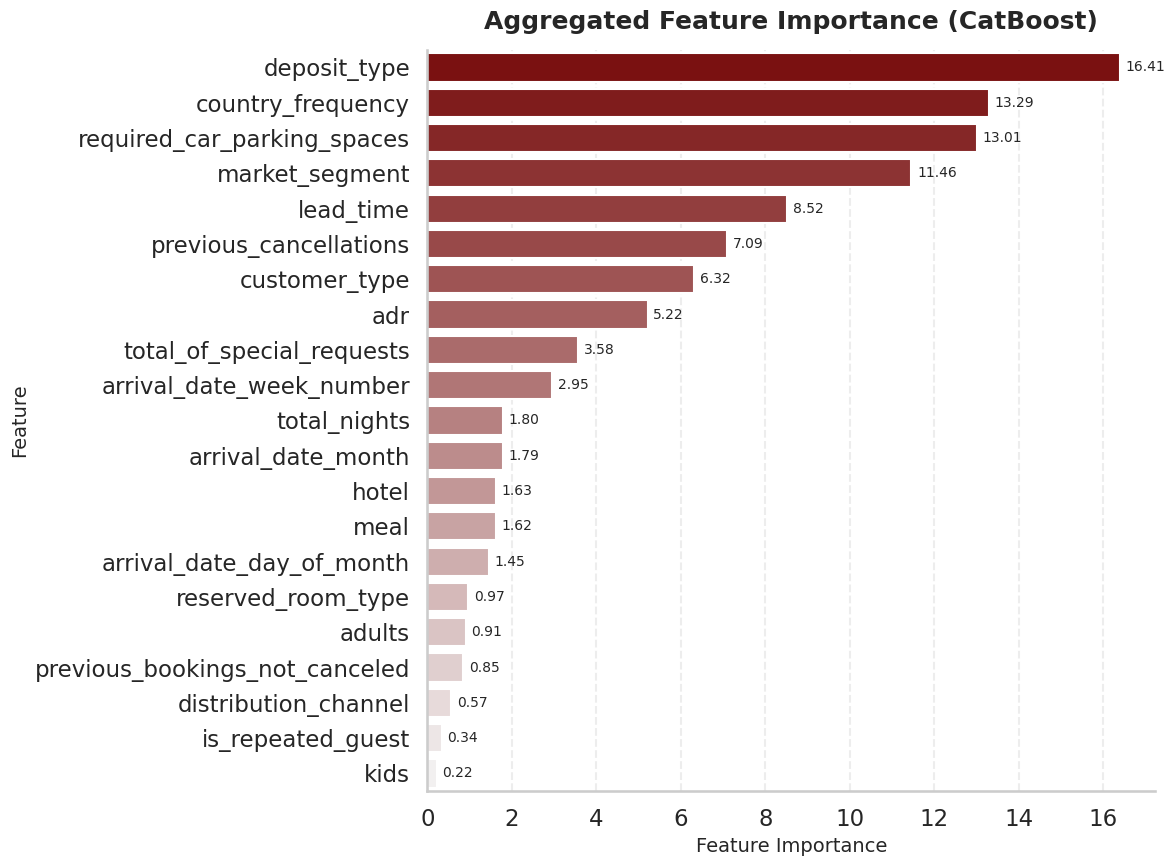

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# AGGREGATED FEATURE IMPORTANCE
# =====================================================

# Ensure descending order
plot_df = aggregated_importance.sort_values(
    by="Importance",
    ascending=False
)

sns.set_theme(
    style="whitegrid",
    context="talk"
)

# Dark red (highest) → Light red (lowest)
colors = sns.light_palette(
    "#8B0000",
    n_colors=len(plot_df),
    reverse=True
)

plt.figure(figsize=(12, 9))

ax = sns.barplot(
    data=plot_df,
    x="Importance",
    y="Original Feature",
    palette=colors
)

# Titles
ax.set_title(
    "Aggregated Feature Importance (CatBoost)",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Feature Importance", fontsize=14)
ax.set_ylabel("Feature", fontsize=14)

# Value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=4,
        fontsize=10
    )

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.grid(axis="y", visible=False)

sns.despine()

plt.tight_layout()
plt.show()

### ROC-AUC Curve for best model

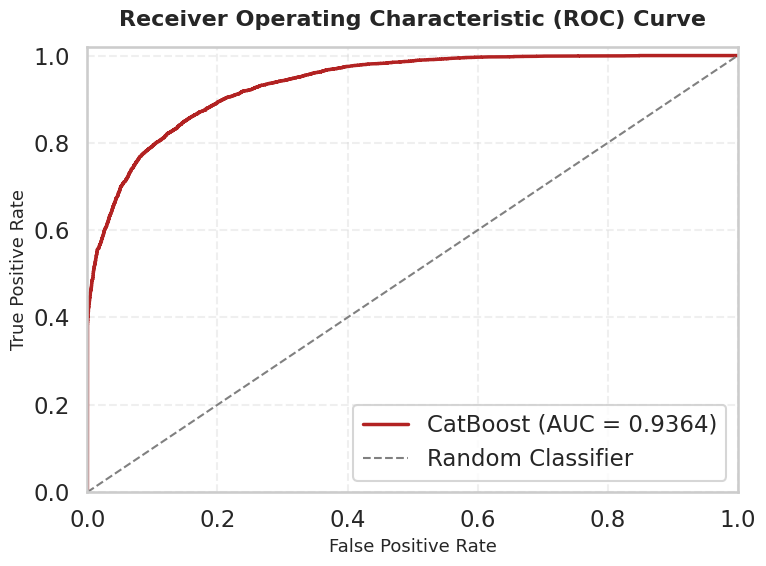

ROC-AUC Score: 0.9364


In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# =====================================================
# ROC CURVE
# =====================================================

# Predicted probabilities
y_prob = best_estimator.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    color="#B22222",
    linewidth=2.5,
    label=f"CatBoost (AUC = {auc:.4f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.xlabel(
    "False Positive Rate",
    fontsize=13
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13
)

plt.title(
    "Receiver Operating Characteristic (ROC) Curve",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.legend(
    loc="lower right",
    frameon=True
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

print(f"ROC-AUC Score: {auc:.4f}")

### SHAP

In [ ]:
!pip install shap

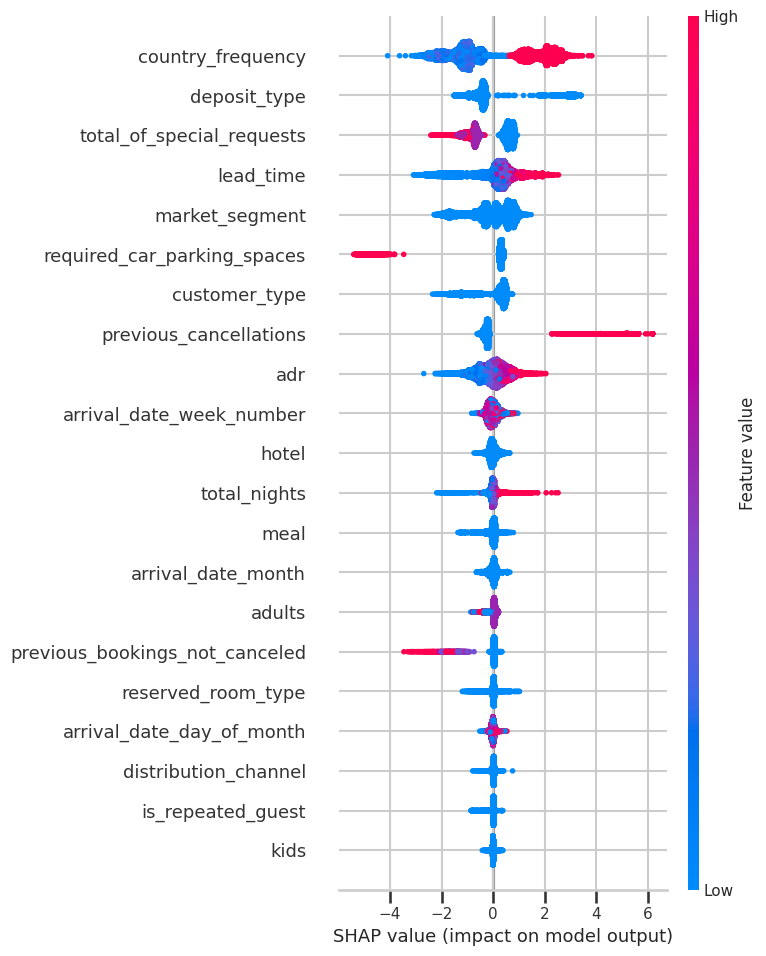

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# =====================================================
# GET FITTED PIPELINE
# =====================================================

preprocessor = best_estimator.named_steps["preprocessor"]
model = best_estimator.named_steps["model"]

# =====================================================
# TRANSFORM TEST DATA
# =====================================================

X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

# =====================================================
# COMPUTE SHAP VALUES
# =====================================================

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# =====================================================
# MAP ENCODED FEATURES TO ORIGINAL FEATURES
# =====================================================

feature_mapping = []

for feature in feature_names:

    if feature.startswith("num__"):
        feature_mapping.append(feature.replace("num__", ""))

    elif feature.startswith("cat__"):

        feature = feature.replace("cat__", "")

        matched = False

        for col in categorical_cols:
            if feature.startswith(col + "_"):
                feature_mapping.append(col)
                matched = True
                break

        if not matched:
            feature_mapping.append(feature)

# =====================================================
# AGGREGATE SHAP VALUES
# =====================================================

aggregated_shap = pd.DataFrame(shap_values, columns=feature_mapping)

aggregated_shap = aggregated_shap.T.groupby(level=0).sum().T

# =====================================================
# AGGREGATE FEATURE VALUES
# =====================================================

X_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_mapping
)

X_aggregated = (
    X_transformed_df
    .T
    .groupby(level=0)
    .sum()
    .T
)

# =====================================================
# SHAP SUMMARY PLOT (AGGREGATED FEATURES)
# =====================================================

plt.figure(figsize=(12,8))

shap.summary_plot(
    aggregated_shap.values,
    X_aggregated,
    feature_names=X_aggregated.columns,
    max_display=len(X_aggregated.columns),
    show=False
)

plt.tight_layout()
plt.show()

Top 10 Features:
['country_frequency', 'deposit_type', 'total_of_special_requests', 'lead_time', 'market_segment', 'required_car_parking_spaces', 'customer_type', 'previous_cancellations', 'adr', 'arrival_date_week_number']


<Figure size 700x500 with 0 Axes>

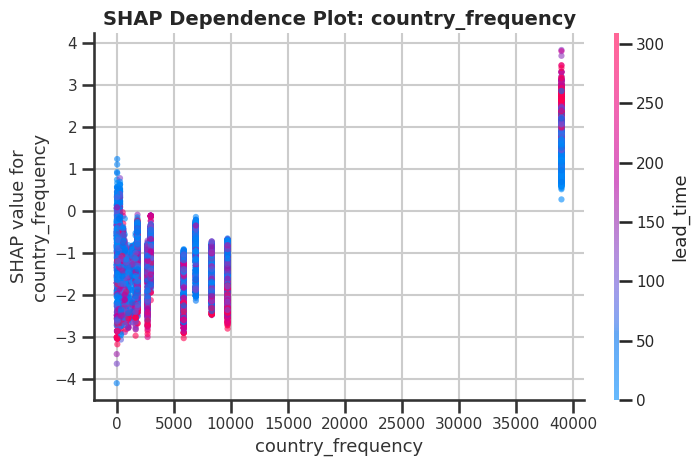

<Figure size 700x500 with 0 Axes>

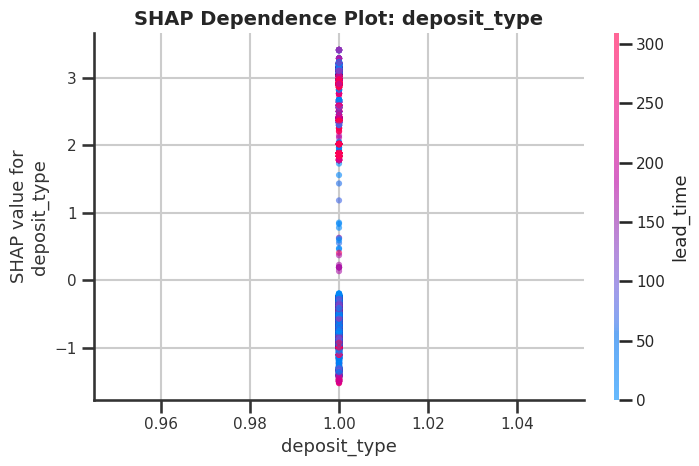

<Figure size 700x500 with 0 Axes>

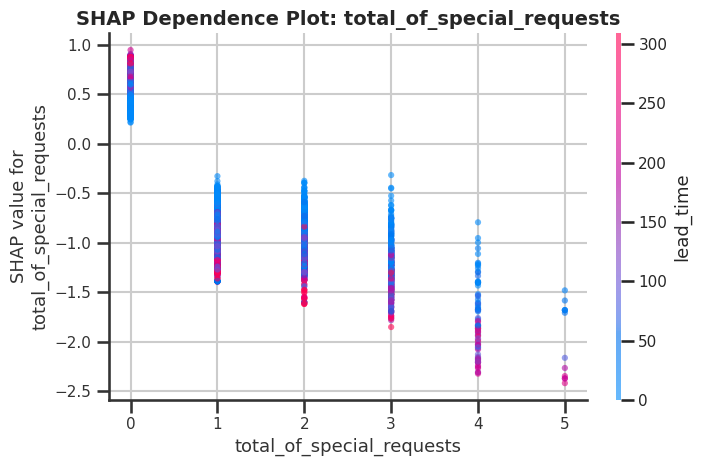

<Figure size 700x500 with 0 Axes>

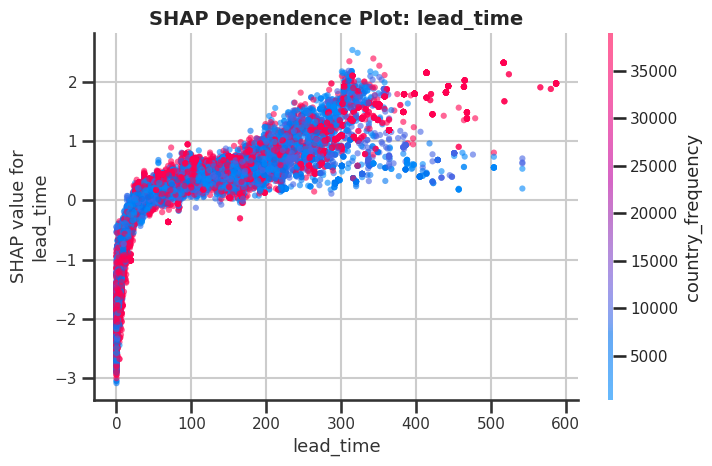

<Figure size 700x500 with 0 Axes>

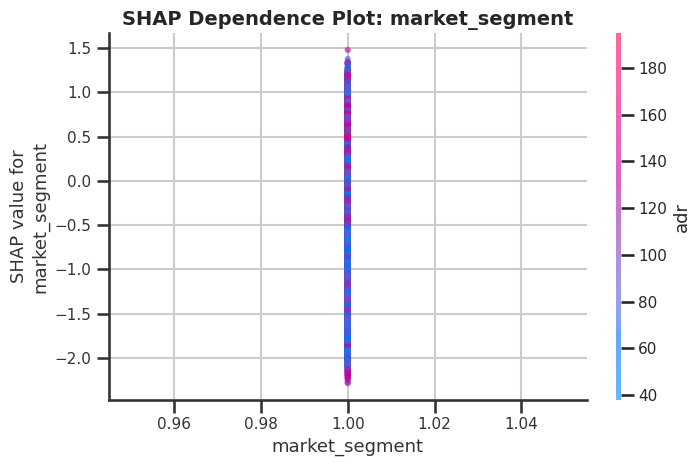

<Figure size 700x500 with 0 Axes>

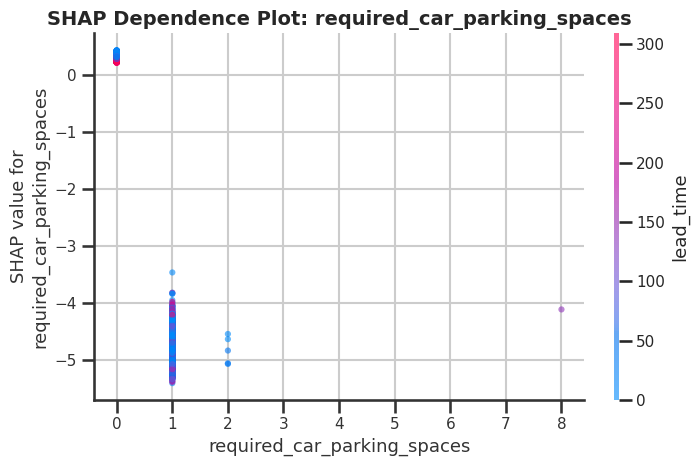

<Figure size 700x500 with 0 Axes>

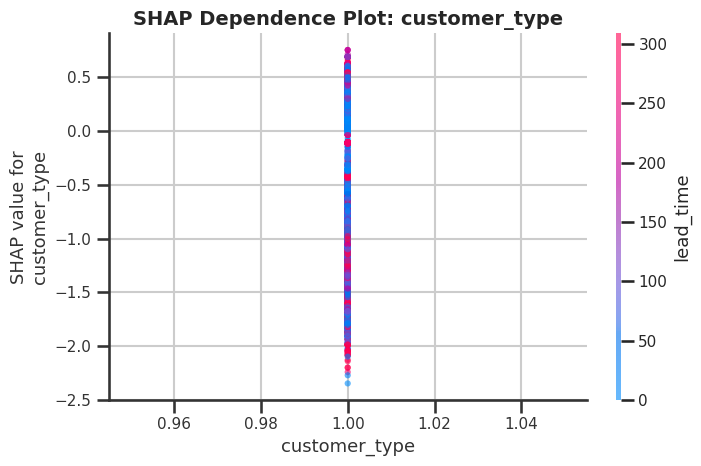

<Figure size 700x500 with 0 Axes>

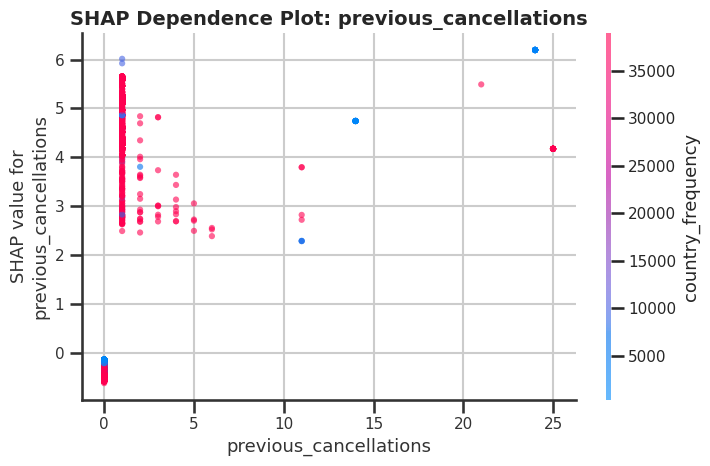

<Figure size 700x500 with 0 Axes>

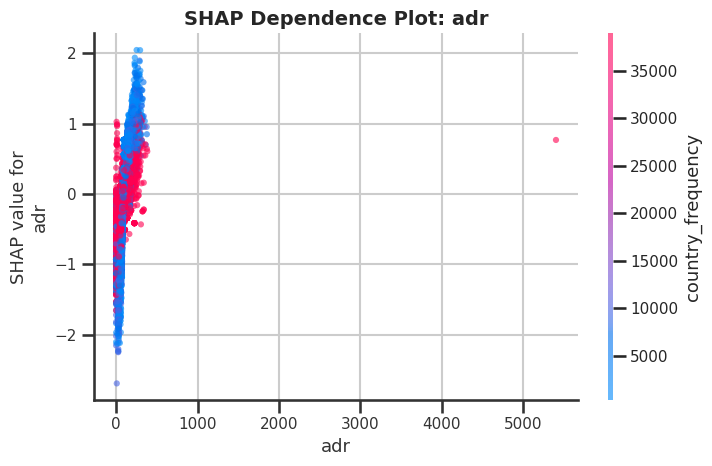

<Figure size 700x500 with 0 Axes>

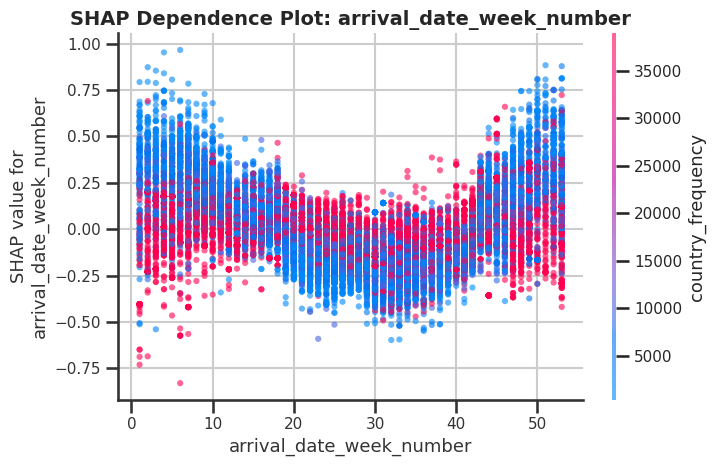

In [ ]:
import shap
import matplotlib.pyplot as plt

# =====================================================
# TOP 10 FEATURES BASED ON MEAN |SHAP|
# =====================================================

mean_abs_shap = (
    abs(aggregated_shap)
    .mean()
    .sort_values(ascending=False)
)

top10_features = mean_abs_shap.head(10).index.tolist()

print("Top 10 Features:")
print(top10_features)

# =====================================================
# SHAP DEPENDENCE PLOTS
# =====================================================

for feature in top10_features:

    plt.figure(figsize=(7, 5))

    shap.dependence_plot(
        ind=feature,
        shap_values=aggregated_shap.values,
        features=X_aggregated,
        feature_names=X_aggregated.columns.tolist(),
        interaction_index="auto",
        alpha=0.6,
        dot_size=20,
        show=False
    )

    plt.title(
        f"SHAP Dependence Plot: {feature}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

### Partial Dependency Plots

Top 10 Numerical Features:
['country_frequency', 'required_car_parking_spaces', 'lead_time', 'previous_cancellations', 'adr', 'total_of_special_requests', 'arrival_date_week_number', 'total_nights', 'arrival_date_day_of_month', 'adults']


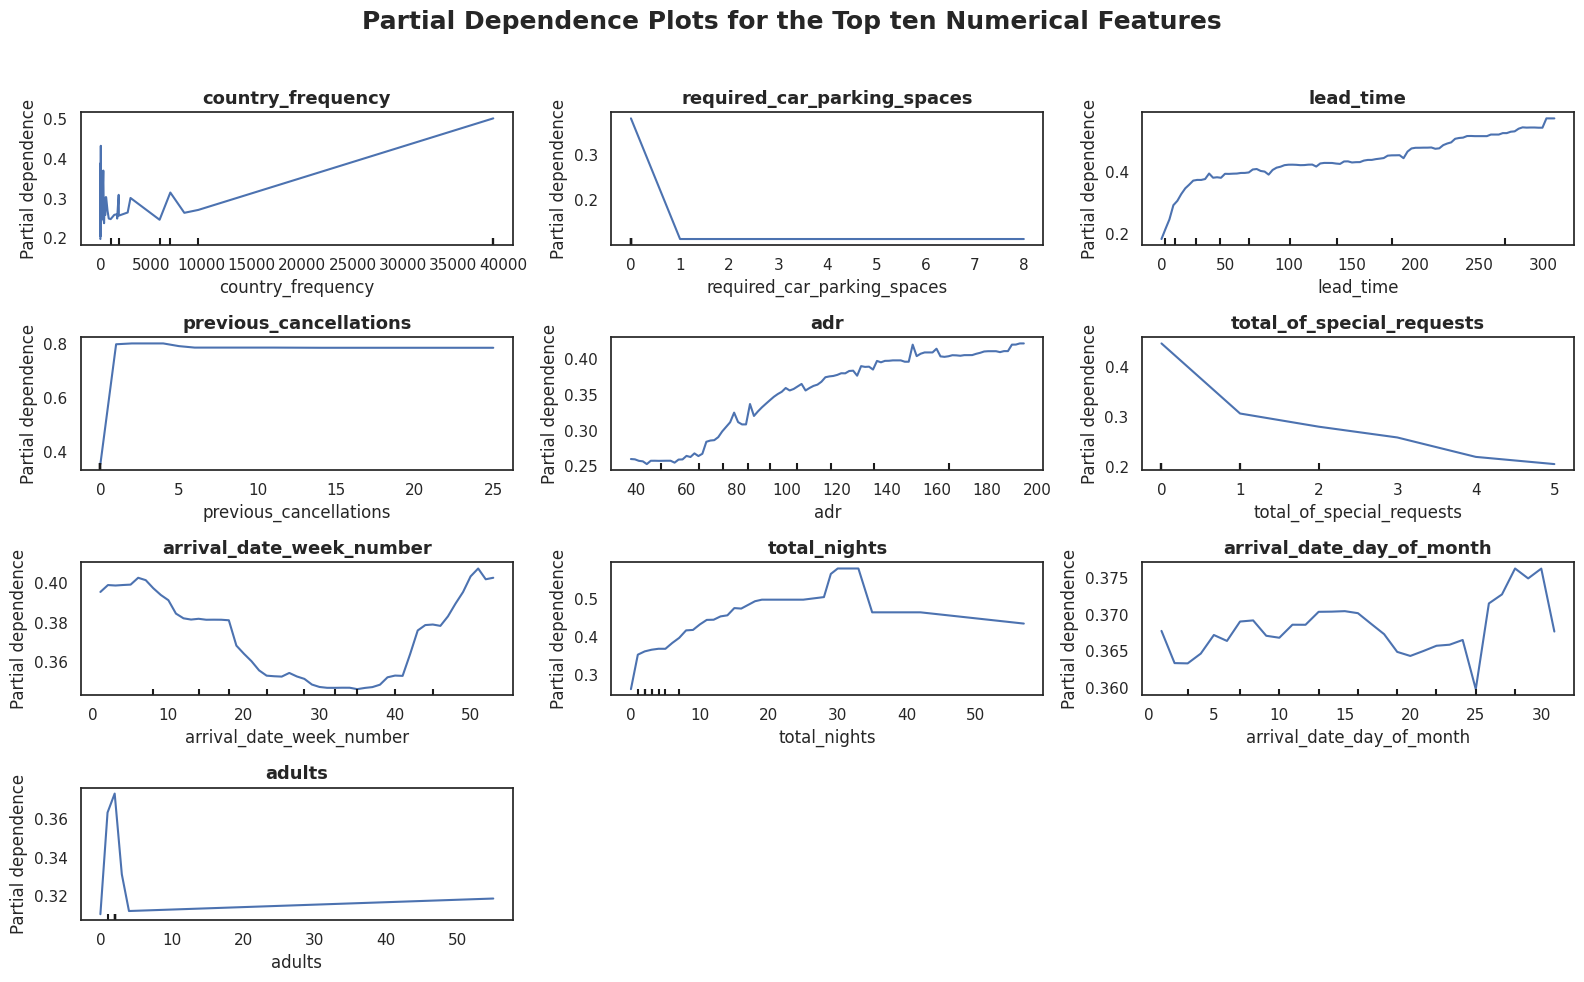

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# =====================================================
# TOP 5 NUMERICAL FEATURES
# =====================================================

top_numeric_features = (
    aggregated_importance[
        aggregated_importance["Original Feature"].isin(numeric_cols)
    ]
    .sort_values("Importance", ascending=False)
    .head(10)["Original Feature"]
    .tolist()
)

print("Top 10 Numerical Features:")
print(top_numeric_features)

# =====================================================
# PARTIAL DEPENDENCE PLOTS
# =====================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(16, 10)
)

axes = axes.flatten()

for i, feature in enumerate(top_numeric_features):

    PartialDependenceDisplay.from_estimator(
        estimator=best_estimator,
        X=X_test,
        features=[feature],
        kind="average",
        grid_resolution=100,
        ax=axes[i]
    )

    axes[i].set_title(
        feature,
        fontsize=13,
        fontweight="bold"
    )

# Remove unused subplot
for j in range(len(top_numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Partial Dependence Plots for the Top ten Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from catboost import CatBoostClassifier

# =====================================================
# SELECT TOP 10 FEATURES
# =====================================================

top10_features = (
    aggregated_importance
    .head(10)["Original Feature"]
    .tolist()
)

print("Top 10 Features")
print(top10_features)

# =====================================================
# REDUCED DATASET
# =====================================================

X_train_top10 = X_train[top10_features].copy()
X_test_top10 = X_test[top10_features].copy()

# =====================================================
# IDENTIFY FEATURE TYPES
# =====================================================

numeric_cols_top10 = X_train_top10.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols_top10 = X_train_top10.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# =====================================================
# PREPROCESSOR
# =====================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols_top10),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols_top10
        )
    ]
)

# =====================================================
# FINAL CATBOOST MODEL
# =====================================================

catboost = CatBoostClassifier(
    random_state=42,
    verbose=0
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", catboost)
])

# =====================================================
# 5-FOLD STRATIFIED CV
# =====================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results = cross_validate(
    pipeline,
    X_train_top10,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# =====================================================
# TRAIN FINAL MODEL
# =====================================================

pipeline.fit(
    X_train_top10,
    y_train
)

# =====================================================
# TEST EVALUATION
# =====================================================

y_pred = pipeline.predict(X_test_top10)

# =====================================================
# RESULTS
# =====================================================

results = pd.DataFrame([{

    "No. Features": len(top10_features),

    "CV Accuracy": cv_results["test_accuracy"].mean(),

    "CV Precision": cv_results["test_precision"].mean(),

    "CV Recall": cv_results["test_recall"].mean(),

    "CV F1": cv_results["test_f1"].mean(),

    "Test Accuracy": accuracy_score(y_test, y_pred),

    "Test Precision": precision_score(y_test, y_pred),

    "Test Recall": recall_score(y_test, y_pred),

    "Test F1": f1_score(y_test, y_pred)

}])

print("\nCatBoost Performance Using Top 10 Features\n")

print(results.round(4).to_string(index=False))

Top 10 Features
['deposit_type', 'country_frequency', 'required_car_parking_spaces', 'market_segment', 'lead_time', 'previous_cancellations', 'customer_type', 'adr', 'total_of_special_requests', 'arrival_date_week_number']

CatBoost Performance Using Top 10 Features

 No. Features  CV Accuracy  CV Precision  CV Recall  CV F1  Test Accuracy  Test Precision  Test Recall  Test F1
           10        0.856        0.8336      0.765 0.7978         0.8516          0.8315       0.7525   0.7901


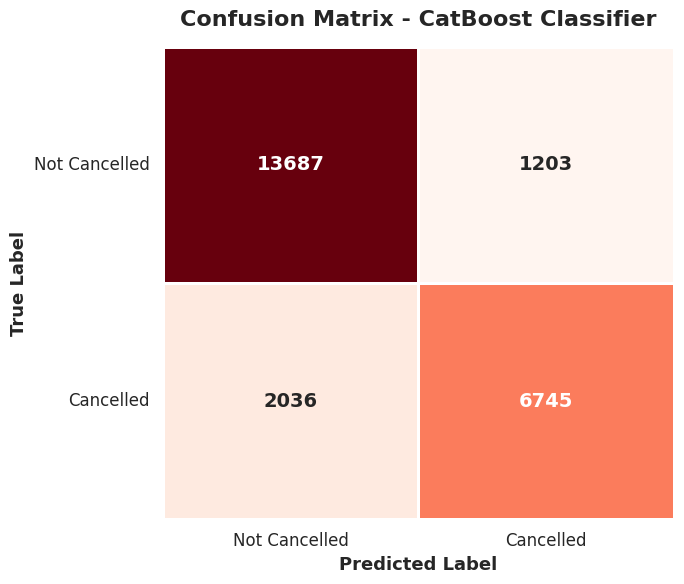


Classification Report

               precision    recall  f1-score   support

Not Cancelled     0.8705    0.9192    0.8942     14890
    Cancelled     0.8486    0.7681    0.8064      8781

     accuracy                         0.8632     23671
    macro avg     0.8596    0.8437    0.8503     23671
 weighted avg     0.8624    0.8632    0.8616     23671



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = best_estimator.predict(X_test)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))

sns.set_theme(style="white")

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=1,
    linecolor="white",
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"}
)

ax.set_title(
    "Confusion Matrix - CatBoost Classifier",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Predicted Label",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "True Label",
    fontsize=13,
    fontweight="bold"
)

# Change labels if your classes are different
ax.set_xticklabels(
    ["Not Cancelled", "Cancelled"],
    fontsize=12
)

ax.set_yticklabels(
    ["Not Cancelled", "Cancelled"],
    fontsize=12,
    rotation=0
)

plt.tight_layout()
plt.show()

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Cancelled", "Cancelled"],
        digits=4
    )
)